# DAMICORE: categorias de abuso

## Proposta de pesquisa

**Pergunta:** as categorias da fonte relacionadas à violência contra mulheres apresentam perfis contextuais recorrentes?

**Unidade de análise:** uma categoria da fonte, não uma pessoa ou uma denúncia. Todas as denúncias com vítima feminina entre janeiro de 2020 e junho de 2026 contribuem para o perfil agregado de cada categoria elegível em que aparecem.

**Escopo operacional:** categorias sob `INTEGRIDADE`, `VIDA` ou `VIOLÊNCIA INSTITUCIONAL`, além de `LIBERDADE > SEXUAL` e da categoria da fonte sobre violência política de gênero. Essa regra da taxonomia da fonte é exploratória, não uma definição jurídica de violência contra a mulher. O primeiro semestre de 2020 preserva rótulos legados sem a hierarquia `>`; esses rótulos ficam fora do subconjunto comparável até uma harmonização específica.

**Representação:** todas as categorias recebem o mesmo vocabulário ordenado de 20 dimensões: as 12 dimensões originais mais início das violações, motivação, raça/cor, escolaridade e renda da vítima, etnia da vítima, faixa etária do suspeito e escolaridade do suspeito. Cada valor é serializado como desvio relativo à distribuição global, em largura fixa de `00000` a `10000`; zero relativo significa exatamente a prevalência global. O suporte total da categoria fica fora do documento comprimido.

**Hipótese exploratória:** categorias com desvios relativos semelhantes de perfil demográfico, relação, ambiente, registro, tempo, motivação e características do suspeito terão menores distâncias NCD, aparecerão próximas na árvore DAMICORE e tenderão a compartilhar um cluster.

A cadeia do experimento é: `desvio contextual relativo → matriz de distâncias NCD → diagnóstico de viés → árvore → clusters DAMICORE → visualizações quantitativas`. A proposta é uma comparação exploratória de perfis contextuais; ela não confirma tipologias jurídicas.


In [51]:
from datetime import datetime
from pathlib import Path
from itertools import combinations
from math import log10, log2
import json
import os
import sys
import textwrap

import matplotlib.pyplot as plt
import pandas as pd
import psycopg
from damicore import estimate, run
from damicore.config import ExecutionConfig, ResourceLimits
from dotenv import load_dotenv
from IPython.display import display
import toytree
import toyplot

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Execute este notebook a partir da raiz do repositório ou do diretório notebooks.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from scripts.damicore_case_experiment import CASE_FIELDS

load_dotenv(PROJECT_ROOT / ".env")
DATABASE_URL = os.getenv("DISQUE100_DATABASE_URL", "postgresql://postgres@127.0.0.1:5433/disque100")
START_DATE = "2020-01-01"
END_DATE = "2026-07-01"
VICTIM_GENDER = "FEMININO"
MIN_REPORT_COUNT = 50
SMOOTHING_ALPHA = 20
LOG_RATIO_LIMIT = 4.0
BIAS_WARNING_THRESHOLD = 0.70

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "damicore_abuse_categories_2020_2026"
WORK_DIR = ARTIFACT_DIR / "work"
CORPUS_DIR = WORK_DIR / "normalized-corpus"
RESULTS_DIR = ARTIFACT_DIR / "results"
CORPUS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def wrapped_label(text, width=30):
    return '\n'.join(textwrap.wrap(text, width=width))

VISUAL_STYLE = {
    'font_size': 7,
    'text_color': '#263238',
    'grid_color': '#E2E7E9',
    'accent_color': '#2A6F97',
    'accent_light': '#CFE4EE',
}


## 1. Cobertura, escopo e contextos agregados

`source_hash` é usado somente dentro do PostgreSQL para contar denúncias distintas. O notebook recebe totais de cobertura e contagens agregadas, nunca denúncias individuais. Valores nulos, vazios ou apenas espaços nas 20 dimensões recebem `DESCONHECIDO` para que toda denúncia permaneça representada.


In [52]:
category_sql = '''
nullif(concat_ws(' > ',
    nullif(trim(split_part(violation, '>', 1)), ''),
    nullif(trim(split_part(violation, '>', 2)), '')
), '')
'''

coverage_query = f'''
WITH reports AS (
    SELECT source_hash,
           bool_or(violation IS NOT NULL) AS has_violation,
           bool_or(({category_sql}) IS NOT NULL) AS has_category
    FROM public.disque100_reports
    WHERE registered_at >= %s AND registered_at < %s
      AND victim_gender = %s
    GROUP BY source_hash
)
SELECT count(*) AS female_reports,
       count(*) FILTER (WHERE has_category) AS reports_with_category,
       count(*) FILTER (WHERE NOT has_violation) AS reports_without_violation
FROM reports
'''

context_query = f'''
WITH report_values AS (
    SELECT DISTINCT
        source_hash,
        {category_sql} AS category,
        coalesce(nullif(trim(victim_age_group), ''), 'DESCONHECIDO') AS age_group,
        coalesce(nullif(trim(victim_suspect_relationship), ''), 'DESCONHECIDO') AS relationship,
        coalesce(nullif(trim(violation_setting), ''), 'DESCONHECIDO') AS setting,
        to_char(date_trunc('month', registered_at), 'YYYY-MM') AS month,
        coalesce(nullif(trim(violation_start_period), ''), 'DESCONHECIDO') AS violation_start_period,
        coalesce(nullif(trim(service_channel), ''), 'DESCONHECIDO') AS service_channel,
        coalesce(nullif(trim(reporter_type), ''), 'DESCONHECIDO') AS reporter_type,
        coalesce(nullif(trim(frequency), ''), 'DESCONHECIDO') AS frequency,
        coalesce(nullif(trim(emergency_status), ''), 'DESCONHECIDO') AS emergency_status,
        coalesce(nullif(trim(motivation), ''), 'DESCONHECIDO') AS motivation,
        coalesce(nullif(trim(vulnerable_group), ''), 'DESCONHECIDO') AS vulnerable_group,
        coalesce(nullif(trim(victim_disability), ''), 'DESCONHECIDO') AS victim_disability,
        coalesce(nullif(trim(victim_race_color), ''), 'DESCONHECIDO') AS victim_race_color,
        coalesce(nullif(trim(victim_education_level), ''), 'DESCONHECIDO') AS victim_education_level,
        coalesce(nullif(trim(victim_income_range), ''), 'DESCONHECIDO') AS victim_income_range,
        coalesce(nullif(trim(victim_ethnicity), ''), 'DESCONHECIDO') AS victim_ethnicity,
        coalesce(nullif(trim(suspect_age_group), ''), 'DESCONHECIDO') AS suspect_age_group,
        coalesce(nullif(trim(suspect_gender), ''), 'DESCONHECIDO') AS suspect_gender,
        coalesce(nullif(trim(suspect_education_level), ''), 'DESCONHECIDO') AS suspect_education_level,
        coalesce(nullif(trim(suspect_legal_nature), ''), 'DESCONHECIDO') AS suspect_legal_nature
    FROM public.disque100_reports
    WHERE registered_at >= %s AND registered_at < %s
      AND victim_gender = %s
), contexts AS (
    SELECT category, source_hash, 'denuncia'::text AS dimension, 'TODAS'::text AS value
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'faixa_etaria', age_group
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'relacao_vitima_suspeito', relationship
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'ambiente', setting
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'mes', month
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'inicio_violacoes', violation_start_period
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'canal_atendimento', service_channel
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'tipo_denunciante', reporter_type
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'frequencia', frequency
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'situacao_emergencia', emergency_status
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'motivacao', motivation
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'grupo_vulneravel', vulnerable_group
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'deficiencia_vitima', victim_disability
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'raca_cor_vitima', victim_race_color
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'escolaridade_vitima', victim_education_level
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'renda_vitima', victim_income_range
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'etnia_vitima', victim_ethnicity
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'faixa_etaria_suspeito', suspect_age_group
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'genero_suspeito', suspect_gender
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'escolaridade_suspeito', suspect_education_level
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'natureza_juridica_suspeito', suspect_legal_nature
    FROM report_values WHERE category IS NOT NULL
)
SELECT category, dimension, value, count(DISTINCT source_hash) AS report_count
FROM contexts
GROUP BY category, dimension, value
ORDER BY category, dimension, value
'''

parameters = (START_DATE, END_DATE, VICTIM_GENDER)
with psycopg.connect(DATABASE_URL) as connection:
    with connection.cursor() as cursor:
        cursor.execute(coverage_query, parameters)
        coverage = pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])
        cursor.execute(context_query, parameters)
        context_counts = pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])


### Context Counts Overview

`context_counts` is the long-form aggregate table with columns `category`, `dimension`, `value`, `report_count`. `report_count` counts distinct `source_hash`.

SQL result: 814,694 category-context rows


,category,report_count
11177,INTEGRIDADE > PSÍQUICA,1121598
9703,INTEGRIDADE > FÍSICA,1100754
10247,INTEGRIDADE > NEGLIGÊNCIA,835748
10649,INTEGRIDADE > PATRIMONIAL,200197
13503,LIBERDADE > SEXUAL,147380
12137,LIBERDADE > DIREITOS INDIVIDUAIS,85189
6758,DIREITOS SOCIAIS > SAÚDE,43402
7256,DIREITOS SOCIAIS > SEGURANÇA,40433
5917,DIREITOS SOCIAIS > PROTEÇÃO À INFÂNCIA,36784
3284,DIREITOS SOCIAIS > ALIMENTAÇÃO,32389


Table too large to display entirely (814694 rows), showing head:


,category,dimension,value,report_count
0,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,ambiente,AMBIENTE DE LAZER/ESPORTE/ENTRETENIMENTO,11
1,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,ambiente,AMBIENTE VIRTUAL (NO ÂMBITO DA INTERNET),139
2,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,ambiente,BERÇÁRIO/CRECHE,7
3,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,ambiente,CASA DA VÍTIMA,1009
4,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,ambiente,CASA DE FAMILIARES,9


/var/folders/bg/zjwnpvh52wg23tybw4xm2kt40000gn/T/ipykernel_63715/3686578564.py:76: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  figure.savefig(RESULTS_DIR / 'category-context-counts-heatmap.png', dpi=180, bbox_inches='tight', facecolor='white')
/Users/erickpatrickbarcelos/codes/data-mining/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


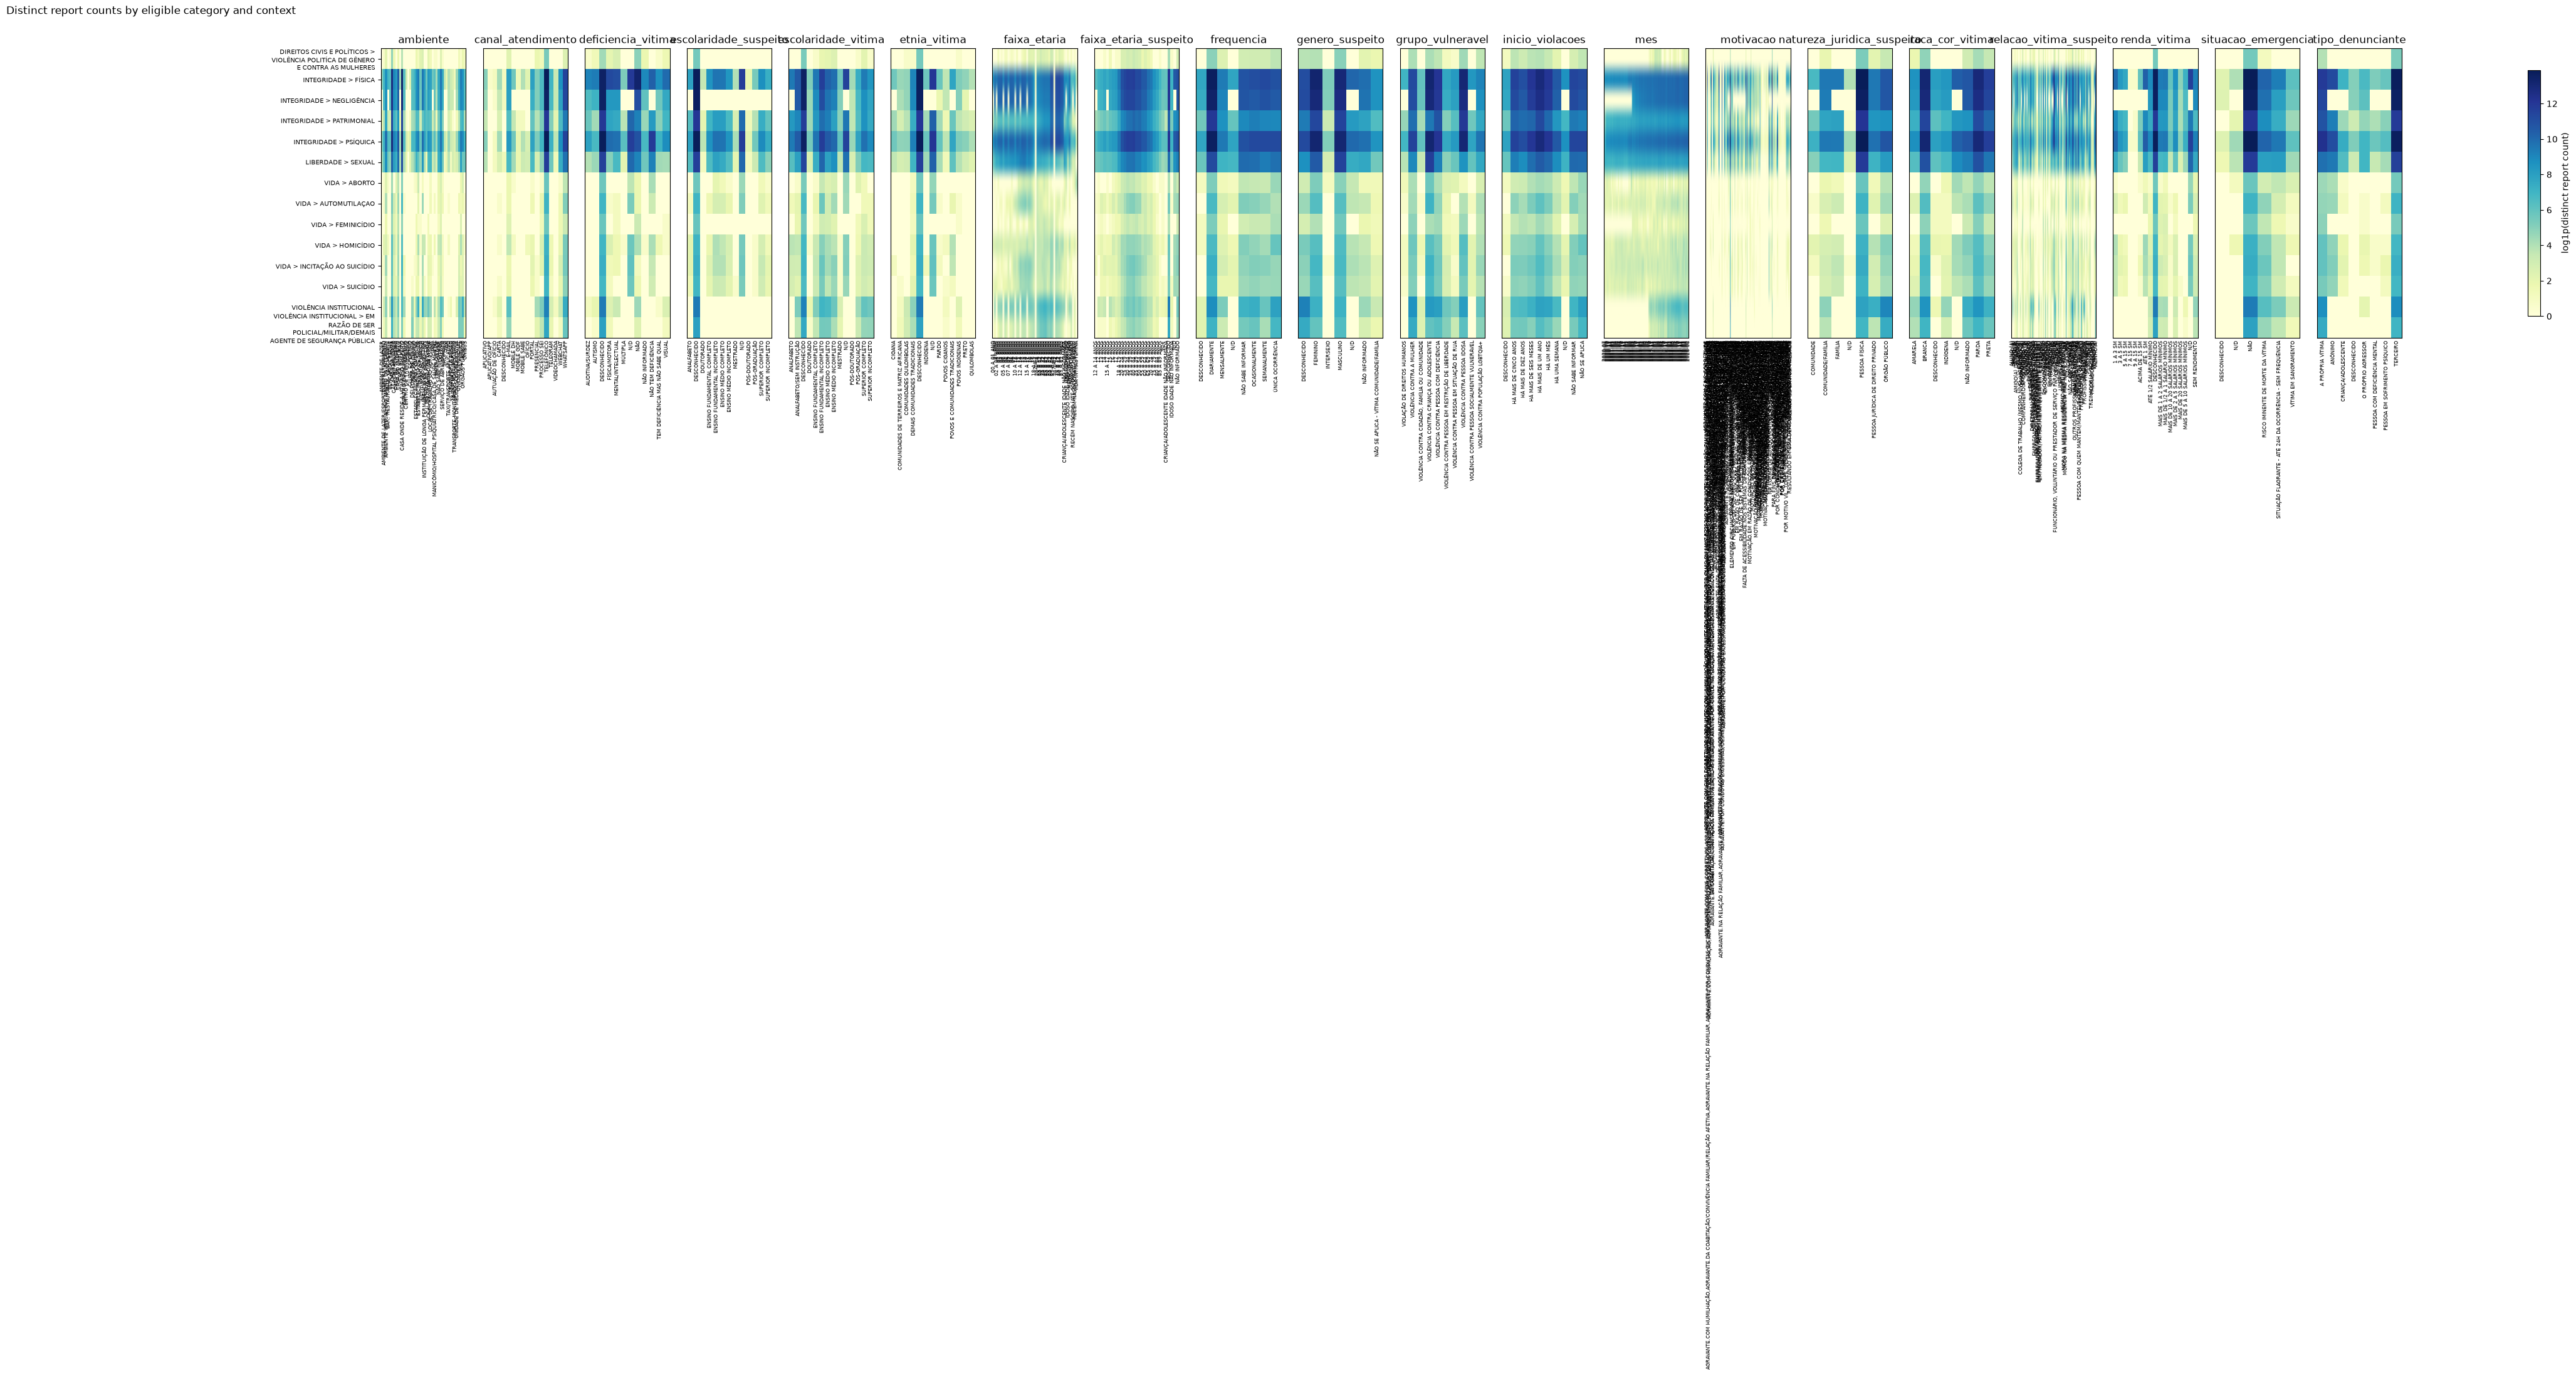

In [53]:
import numpy as np

# Assertions
assert set(context_counts.columns) == {'category', 'dimension', 'value', 'report_count'}
assert 'denuncia' in context_counts['dimension'].values

# Compact category summary
category_summary = context_counts.loc[
    context_counts['dimension'] == 'denuncia', ['category', 'report_count']
].sort_values('report_count', ascending=False)
print(f"SQL result: {len(context_counts):,} category-context rows")
display(category_summary.head(50))

# Display complete table if reasonably sized
if len(context_counts) < 1000:
    display(context_counts)
else:
    print(f"Table too large to display entirely ({len(context_counts)} rows), showing head:")
    display(context_counts.head())

# Keep the heatmap focused on the categories that will become DAMICORE objects.
selected_categories = category_summary.loc[
    (
        category_summary['category'].str.startswith(('INTEGRIDADE', 'VIDA', 'VIOLÊNCIA INSTITUCIONAL'))
        | category_summary['category'].eq('LIBERDADE > SEXUAL')
        | category_summary['category'].str.contains(
            'VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES', regex=False
        )
    )
    & category_summary['report_count'].ge(MIN_REPORT_COUNT),
    'category',
].tolist()
assert selected_categories
heatmap_source = context_counts.loc[
    context_counts['category'].isin(selected_categories)
    & context_counts['dimension'].ne('denuncia')
].copy()
assert heatmap_source['dimension'].nunique() > 0
# The heatmap source should be raw context_counts as requested.

dimensions = sorted(heatmap_source['dimension'].unique())
categories = sorted(selected_categories)
global_log_vmax = max(1.0, float(np.log1p(heatmap_source['report_count'].max())))

figure, axes = plt.subplots(
    1, len(dimensions),
    figsize=(max(18, 2.6 * len(dimensions)), max(6, 0.42 * len(categories))),
    sharey=True, squeeze=False, constrained_layout=True,
)
axes = axes[0]
image = None

for ax, dim in zip(axes, dimensions):
    dim_data = heatmap_source[heatmap_source['dimension'] == dim]
    pivot_df = dim_data.pivot(index='category', columns='value', values='report_count').fillna(0)
    pivot_df = pivot_df.reindex(categories, fill_value=0)

    image = ax.imshow(
        np.log1p(pivot_df.to_numpy()), aspect='auto', cmap='YlGnBu',
        vmin=0, vmax=global_log_vmax,
    )
    ax.set_title(dim)
    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_xticklabels(pivot_df.columns, rotation=90, fontsize=6)
    ax.tick_params(axis='x', length=0)
    if ax is axes[0]:
        ax.set_yticks(np.arange(len(categories)))
        ax.set_yticklabels([wrapped_label(category, width=28) for category in categories], fontsize=7)
    else:
        ax.tick_params(axis='y', length=0)


figure.suptitle('Distinct report counts by eligible category and context', ha='left', x=0.01)
figure.colorbar(image, ax=axes.tolist(), label='log1p(distinct report count)', shrink=0.85)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
figure.savefig(RESULTS_DIR / 'category-context-counts-heatmap.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

,Denúncias com vítima feminina,Denúncias com categoria,Denúncias sem violação
0,1421122,1420747,0


,dimension,category_count,value_count
0,ambiente,34291,52
1,canal_atendimento,34291,24
2,deficiencia_vitima,34291,12
3,escolaridade_suspeito,34291,14
4,escolaridade_vitima,34291,15
5,etnia_vitima,34291,14
6,faixa_etaria,34291,71
7,faixa_etaria_suspeito,34291,50
8,frequencia,34291,8
9,genero_suspeito,34291,8


,eligible_category_count
dimension,
ambiente,14
canal_atendimento,14
deficiencia_vitima,14
escolaridade_suspeito,14
escolaridade_vitima,14
etnia_vitima,14
faixa_etaria,14
faixa_etaria_suspeito,14
frequencia,14


Categorias da fonte: 34291
Categorias incluídas no DAMICORE: 14
Suporte mínimo: 50 denúncias distintas


,category,category_report_count,status
2778,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,247,incluída
9703,INTEGRIDADE > FÍSICA,1100754,incluída
10247,INTEGRIDADE > NEGLIGÊNCIA,835748,incluída
10649,INTEGRIDADE > PATRIMONIAL,200197,incluída
11177,INTEGRIDADE > PSÍQUICA,1121598,incluída
13503,LIBERDADE > SEXUAL,147380,incluída
15858,VIDA > ABORTO,393,incluída
16153,VIDA > AUTOMUTILAÇAO,1322,incluída
16493,VIDA > FEMINICÍDIO,343,incluída
16851,VIDA > HOMICÍDIO,1517,incluída


,category,category_report_count,status
53,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,2486,fora do escopo operacional
443,DIREITOS CIVIS E POLÍTICOS > CULTURAL,158,fora do escopo operacional
733,DIREITOS CIVIS E POLÍTICOS > LIVRE EXERCÍCIO D...,5056,fora do escopo operacional
1143,DIREITOS CIVIS E POLÍTICOS > MEMÓRIA E VERDADE,364,fora do escopo operacional
1416,DIREITOS CIVIS E POLÍTICOS > NACIONALIDADE,74,fora do escopo operacional
...,...,...,...
814584,violencia_violacoes_gerais.VIOLÊNCIA PATRIMONI...,1,fora do escopo operacional
814605,violencia_violacoes_gerais.VIOLÊNCIA PATRIMONI...,1,fora do escopo operacional
814627,violencia_violacoes_gerais.VIOLÊNCIA PATRIMONI...,2,fora do escopo operacional
814655,violencia_violacoes_gerais.VIOLÊNCIA PATRIMONI...,1,fora do escopo operacional


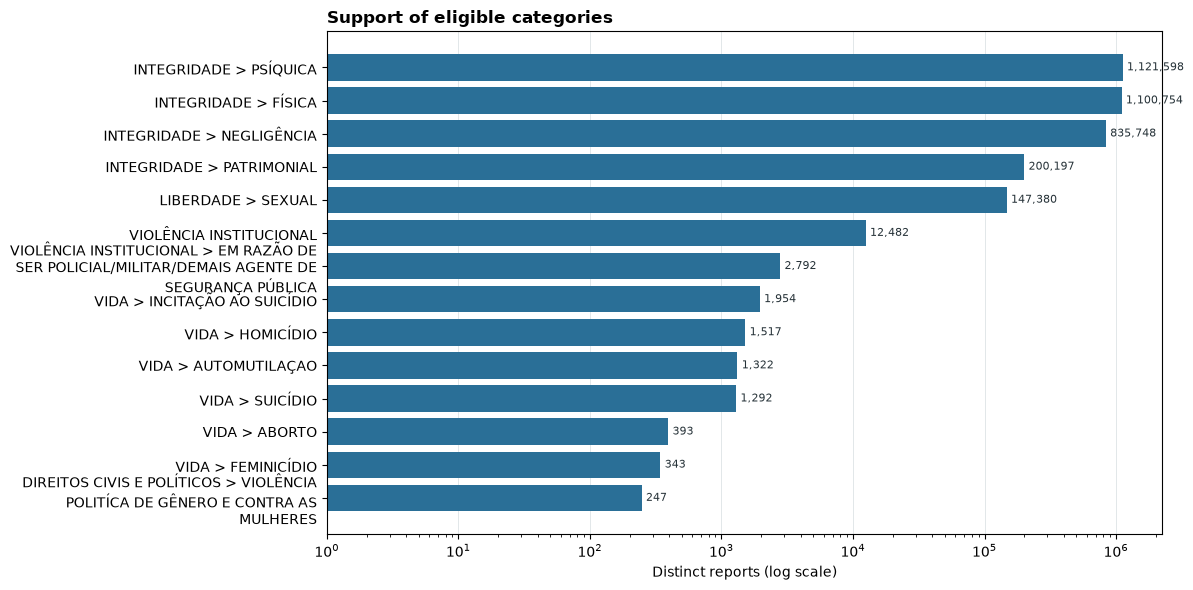

In [54]:

display(coverage.rename(columns={
    "female_reports": "Denúncias com vítima feminina",
    "reports_with_category": "Denúncias com categoria",
    "reports_without_violation": "Denúncias sem violação",
}))
expected_dimension_labels = {label for _, label in CASE_FIELDS}
actual_dimension_labels = set(context_counts["dimension"].unique()) - {"denuncia"}
assert len(expected_dimension_labels) == 20
assert actual_dimension_labels == expected_dimension_labels
dimension_summary = (
    context_counts.loc[context_counts["dimension"].ne("denuncia")]
    .groupby("dimension", as_index=False)
    .agg(category_count=("category", "nunique"), value_count=("value", "nunique"))
    .sort_values("dimension")
)
display(dimension_summary)

category_support = (
    context_counts.loc[context_counts["dimension"] == "denuncia", ["category", "report_count"]]
    .rename(columns={"report_count": "category_report_count"})
    .sort_values("category")
)

scope_mask = (
    category_support["category"].str.startswith(("INTEGRIDADE", "VIDA", "VIOLÊNCIA INSTITUCIONAL"))
    | category_support["category"].eq("LIBERDADE > SEXUAL")
    | category_support["category"].str.contains(
        "VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES", regex=False
    )
)
category_support["status"] = "incluída"
category_support.loc[~scope_mask, "status"] = "fora do escopo operacional"
category_support.loc[
    scope_mask & (category_support["category_report_count"] < MIN_REPORT_COUNT), "status"
] = "abaixo do suporte mínimo"

included_support = category_support.loc[category_support["status"] == "incluída"].copy()
excluded_categories = category_support.loc[category_support["status"] != "incluída"].copy()
included_categories = included_support["category"].tolist()
included_dimension_coverage = (
    context_counts.loc[
        context_counts["category"].isin(included_categories)
        & context_counts["dimension"].ne("denuncia")
    ]
    .groupby("dimension")["category"]
    .nunique()
)
assert set(included_dimension_coverage.index) == expected_dimension_labels
assert included_dimension_coverage.eq(len(included_categories)).all()
display(included_dimension_coverage.rename("eligible_category_count").to_frame())


print(f"Categorias da fonte: {len(category_support)}")
print(f"Categorias incluídas no DAMICORE: {len(included_support)}")
print(f"Suporte mínimo: {MIN_REPORT_COUNT} denúncias distintas")
display(included_support)
display(excluded_categories)


support_plot = included_support.sort_values("category_report_count")
figure, axis = plt.subplots(
    figsize=(12, max(6, 0.42 * len(support_plot))),
)
axis.barh(
    [wrapped_label(category, width=38) for category in support_plot["category"]],
    support_plot["category_report_count"],
    color=VISUAL_STYLE["accent_color"],
)
axis.set_xscale("log")
axis.set_xlabel("Distinct reports (log scale)")
axis.set_title("Support of eligible categories", loc="left", weight="bold")
axis.grid(axis="x", color=VISUAL_STYLE["grid_color"], linewidth=0.7)
axis.set_axisbelow(True)
axis.set_xlim(1, support_plot["category_report_count"].max() * 2)
for position, value in enumerate(support_plot["category_report_count"]):
    axis.text(
        value * 1.08,
        position,
        f"{int(value):,}",
        va="center",
        fontsize=8,
        color=VISUAL_STYLE["text_color"],
    )
figure.tight_layout()
figure.savefig(
    RESULTS_DIR / "category-support.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()


## 2. Documento normalizado de largura fixa por categoria elegível

O total da categoria é usado como denominador. O documento agora usa 20 dimensões, com `mes` representando o registro e `inicio_violacoes` representando o período informado para o início da violência. Para reduzir o ruído de categorias raras, usamos suavização empírica com `alpha=20`: `(contagem + alpha * prevalência_global) / (suporte + alpha)`. Em seguida, calculamos `log2(prevalência_suavizada / prevalência_global)`. Assim, zero representa o padrão global, valores positivos indicam sobre-representação e valores negativos indicam sub-representação. O resultado é codificado em largura fixa (`00000` a `10000`) para todas as categorias.


In [55]:
for old_file in CORPUS_DIR.glob("*.txt"):
    old_file.unlink()

profile_counts = context_counts.loc[
    context_counts["category"].isin(included_categories)
    & context_counts["dimension"].ne("denuncia")
].copy()
vocabulary = (
    profile_counts[["dimension", "value"]]
    .drop_duplicates()
    .sort_values(["dimension", "value"])
)
assert set(vocabulary["dimension"]) == expected_dimension_labels
assert len(vocabulary["dimension"].unique()) == 20

normalized_profiles = (
    included_support[["category", "category_report_count"]]
    .merge(vocabulary, how="cross")
    .merge(profile_counts, on=["category", "dimension", "value"], how="left")
    .sort_values(["category", "dimension", "value"])
)
assert normalized_profiles.groupby("category").size().nunique() == 1
normalized_profiles["report_count"] = normalized_profiles["report_count"].fillna(0).astype(int)
global_counts = (
    profile_counts.groupby(["dimension", "value"], as_index=False)["report_count"]
    .sum()
    .rename(columns={"report_count": "global_count"})
)
global_counts["global_prevalence"] = (
    global_counts["global_count"]
    / global_counts.groupby("dimension")["global_count"].transform("sum")
)
normalized_profiles = normalized_profiles.merge(
    global_counts[["dimension", "value", "global_prevalence"]],
    on=["dimension", "value"],
    how="left",
    validate="many_to_one",
)
normalized_profiles["smoothed_prevalence"] = (
    normalized_profiles["report_count"]
    + SMOOTHING_ALPHA * normalized_profiles["global_prevalence"]
) / (normalized_profiles["category_report_count"] + SMOOTHING_ALPHA)
normalized_profiles["relative_log2"] = (
    normalized_profiles["smoothed_prevalence"]
    / normalized_profiles["global_prevalence"]
).map(log2)
normalized_profiles["relative_bps"] = (
    10_000
    * (normalized_profiles["relative_log2"].clip(-LOG_RATIO_LIMIT, LOG_RATIO_LIMIT) + LOG_RATIO_LIMIT)
    / (2 * LOG_RATIO_LIMIT)
).round().astype(int)

category_rows = []
for number, category in enumerate(sorted(included_categories), start=1):
    label = f"category-{number:03d}.txt"
    rows = normalized_profiles.loc[normalized_profiles["category"] == category]
    lines = [
        f"{row.dimension}|{row.value}|{row.relative_bps:05d}"
        for row in rows.itertuples(index=False)
    ]
    (CORPUS_DIR / label).write_text("\n".join(lines) + "\n", encoding="utf-8")
    support = int(rows["category_report_count"].iloc[0])
    category_rows.append({"label": label, "category": category, "report_count": support})

category_map = pd.DataFrame(category_rows)
category_map.to_csv(WORK_DIR / "normalized-category-map.csv", index=False)

corpus_sizes = pd.Series(
    {(path.name): path.stat().st_size for path in CORPUS_DIR.glob("*.txt")},
    name="bytes",
)
assert corpus_sizes.nunique() == 1, "Os documentos normalizados devem ter o mesmo tamanho em bytes."
display(category_map)
print(f"Dimensões contextuais: {len(vocabulary['dimension'].unique())}")
print(f"Chaves contextuais por categoria: {len(vocabulary)}")
print(f"Bytes por documento normalizado: {int(corpus_sizes.iloc[0])}")
print(f"Suavização empírica alpha: {SMOOTHING_ALPHA}")
print(f"Limite do log-ratio: ±{LOG_RATIO_LIMIT}")


,label,category,report_count
0,category-001.txt,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,247
1,category-002.txt,INTEGRIDADE > FÍSICA,1100754
2,category-003.txt,INTEGRIDADE > NEGLIGÊNCIA,835748
3,category-004.txt,INTEGRIDADE > PATRIMONIAL,200197
4,category-005.txt,INTEGRIDADE > PSÍQUICA,1121598
5,category-006.txt,LIBERDADE > SEXUAL,147380
6,category-007.txt,VIDA > ABORTO,393
7,category-008.txt,VIDA > AUTOMUTILAÇAO,1322
8,category-009.txt,VIDA > FEMINICÍDIO,343
9,category-010.txt,VIDA > HOMICÍDIO,1517


Dimensões contextuais: 20
Chaves contextuais por categoria: 574
Bytes por documento normalizado: 26919
Suavização empírica alpha: 20
Limite do log-ratio: ±4.0


## 3. Fluxo mínimo do DAMICORE

A sequência é `estimate → run → membership → matriz de distâncias → árvore`. Valores NCD menores significam perfis contextuais normalizados mais semelhantes. Cada execução recebe automaticamente um diretório com data, hora e microssegundos; por isso, uma execução nova nunca colide com uma execução anterior.


In [56]:
preview = estimate(CORPUS_DIR, source_kind="files")
display(preview.model_dump())
if not preview.within_limits:
    raise RuntimeError(f"Os limites do DAMICORE foram excedidos: {preview.violations}")

RUN_ID = datetime.now().astimezone().strftime("%Y%m%d-%H%M%S-%f")
RUN_DIR = WORK_DIR / f"normalized-run-{RUN_ID}"
print(f"Identificador automático desta execução: {RUN_ID}")
result = run(CORPUS_DIR, source_kind="files", output_dir=RUN_DIR)
try:
    membership = result.membership.copy()
    distance_matrix = result.distance_matrix.to_pandas()
    tree_newick = result.tree_newick
finally:
    result.close()

category_clusters = (
    membership[["object_id", "label", "cluster"]]
    .merge(category_map, on="label", validate="one_to_one")
    .sort_values(["cluster", "category"])
)
category_clusters[["category", "cluster", "report_count"]].to_csv(
    RESULTS_DIR / "category-clusters.csv", index=False
)

label_to_category = category_map.set_index("label")["category"].to_dict()
category_distance_matrix = distance_matrix.rename(
    index=label_to_category, columns=label_to_category
)
clusters = sorted(category_clusters["cluster"].unique())
cluster_palette = [
    "#56B4E9",  # sky blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#F0E442",  # yellow
]
cluster_hex_colors = {
    cluster: cluster_palette[index % len(cluster_palette)]
    for index, cluster in enumerate(clusters)
}

display(category_clusters[["category", "cluster", "report_count"]])
display(category_distance_matrix.round(3))


{'source_kind': 'files',
 'source_paths': (PosixPath('/Users/erickpatrickbarcelos/codes/data-mining/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-001.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/data-mining/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-002.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/data-mining/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-003.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/data-mining/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-004.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/data-mining/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-005.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/data-mining/artifacts/damicore_abuse_categories_2020_2026/work/normalized-corpus/category-006.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/data-mining/artifacts/da

Identificador automático desta execução: 20260917-122523-422315


distance: 100%|██████████| 91/91 [00:00<00:00, 168.53pair/s]


,category,cluster,report_count
0,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,0,247
2,INTEGRIDADE > NEGLIGÊNCIA,0,835748
1,INTEGRIDADE > FÍSICA,1,1100754
3,INTEGRIDADE > PATRIMONIAL,1,200197
4,INTEGRIDADE > PSÍQUICA,1,1121598
5,LIBERDADE > SEXUAL,1,147380
6,VIDA > ABORTO,2,393
9,VIDA > HOMICÍDIO,2,1517
7,VIDA > AUTOMUTILAÇAO,3,1322
10,VIDA > INCITAÇÃO AO SUICÍDIO,3,1954


,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES,INTEGRIDADE > FÍSICA,INTEGRIDADE > NEGLIGÊNCIA,INTEGRIDADE > PATRIMONIAL,INTEGRIDADE > PSÍQUICA,LIBERDADE > SEXUAL,VIDA > ABORTO,VIDA > AUTOMUTILAÇAO,VIDA > FEMINICÍDIO,VIDA > HOMICÍDIO,VIDA > INCITAÇÃO AO SUICÍDIO,VIDA > SUICÍDIO,VIOLÊNCIA INSTITUCIONAL,VIOLÊNCIA INSTITUCIONAL > EM RAZÃO DE SER POLICIAL/MILITAR/DEMAIS AGENTE DE SEGURANÇA PÚBLICA
DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES,0.000,0.597,0.580,0.595,0.600,0.594,0.573,0.577,0.559,0.578,0.576,0.579,0.561,0.559
INTEGRIDADE > FÍSICA,0.597,0.000,0.588,0.571,0.576,0.571,0.609,0.597,0.609,0.584,0.590,0.595,0.607,0.609
INTEGRIDADE > NEGLIGÊNCIA,0.580,0.588,0.000,0.559,0.577,0.553,0.496,0.502,0.462,0.519,0.511,0.504,0.446,0.458
INTEGRIDADE > PATRIMONIAL,0.595,0.571,0.559,0.000,0.581,0.554,0.585,0.579,0.587,0.565,0.569,0.571,0.578,0.582
INTEGRIDADE > PSÍQUICA,0.600,0.576,0.577,0.581,0.000,0.567,0.600,0.592,0.602,0.576,0.586,0.585,0.593,0.599
LIBERDADE > SEXUAL,0.594,0.571,0.553,0.554,0.567,0.000,0.576,0.567,0.584,0.558,0.564,0.569,0.573,0.581
VIDA > ABORTO,0.573,0.609,0.496,0.585,0.600,0.576,0.000,0.443,0.413,0.462,0.452,0.454,0.429,0.429
VIDA > AUTOMUTILAÇAO,0.577,0.597,0.502,0.579,0.592,0.567,0.443,0.000,0.455,0.470,0.452,0.451,0.458,0.461
VIDA > FEMINICÍDIO,0.559,0.609,0.462,0.587,0.602,0.584,0.413,0.455,0.000,0.465,0.455,0.448,0.375,0.362
VIDA > HOMICÍDIO,0.578,0.584,0.519,0.565,0.576,0.558,0.462,0.470,0.465,0.000,0.484,0.484,0.497,0.496


## 4. Verificação de predominância do tamanho ou da popularidade

Estes são diagnósticos de triagem, não testes de significância. Uma correlação absoluta alta (sinalizada aqui a partir de 0,70) significa que a NCD ainda acompanha fortemente o suporte ou o tamanho bruto do documento; nesse caso, os clusters não devem ser interpretados como perfis contextuais.


In [57]:
category_lookup = category_clusters.set_index("label")
pair_rows = []
for left_label, right_label in combinations(distance_matrix.index, 2):
    left = category_lookup.loc[left_label]
    right = category_lookup.loc[right_label]
    pair_rows.append({
        "ncd": float(distance_matrix.loc[left_label, right_label]),
        "support_gap": abs(log10(left["report_count"]) - log10(right["report_count"])),
        "byte_gap": abs(corpus_sizes[left_label] - corpus_sizes[right_label]),
    })

pair_diagnostics = pd.DataFrame(pair_rows)
ncd_rank = pair_diagnostics["ncd"].rank()
support_correlation = ncd_rank.corr(pair_diagnostics["support_gap"].rank())
byte_correlation = ncd_rank.corr(pair_diagnostics["byte_gap"].rank())
diagnostic_summary = pd.DataFrame({
    "diagnostic": ["NCD versus diferença absoluta de suporte em log", "NCD versus diferença de bytes do corpus"],
    "spearman_correlation": [support_correlation, byte_correlation],
})
display(diagnostic_summary.round(3))

if pd.notna(support_correlation) and abs(support_correlation) >= BIAS_WARNING_THRESHOLD:
    print("AVISO: a popularidade das categorias ainda influencia fortemente a NCD; não interprete os clusters.")
else:
    print("A correlação com a diferença de suporte está abaixo do limite de triagem.")
if pd.isna(byte_correlation):
    print("Todos os documentos normalizados têm o mesmo tamanho em bytes; a correlação com a diferença de bytes é indefinida, como esperado.")
elif abs(byte_correlation) >= BIAS_WARNING_THRESHOLD:
    print("AVISO: o tamanho do documento ainda influencia fortemente a NCD; não interprete os clusters.")
else:
    print("A correlação com a diferença de bytes está abaixo do limite de triagem.")


/Users/erickpatrickbarcelos/codes/data-mining/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/erickpatrickbarcelos/codes/data-mining/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,diagnostic,spearman_correlation
0,NCD versus diferença absoluta de suporte em log,0.587
1,NCD versus diferença de bytes do corpus,NaN


A correlação com a diferença de suporte está abaixo do limite de triagem.
Todos os documentos normalizados têm o mesmo tamanho em bytes; a correlação com a diferença de bytes é indefinida, como esperado.


## 5. Matriz de distância NCD

A matriz mostra as distâncias entre as categorias elegíveis. Valores menores indicam mais estrutura compressível compartilhada. A ordem dos eixos segue os clusters DAMICORE para facilitar a comparação visual.


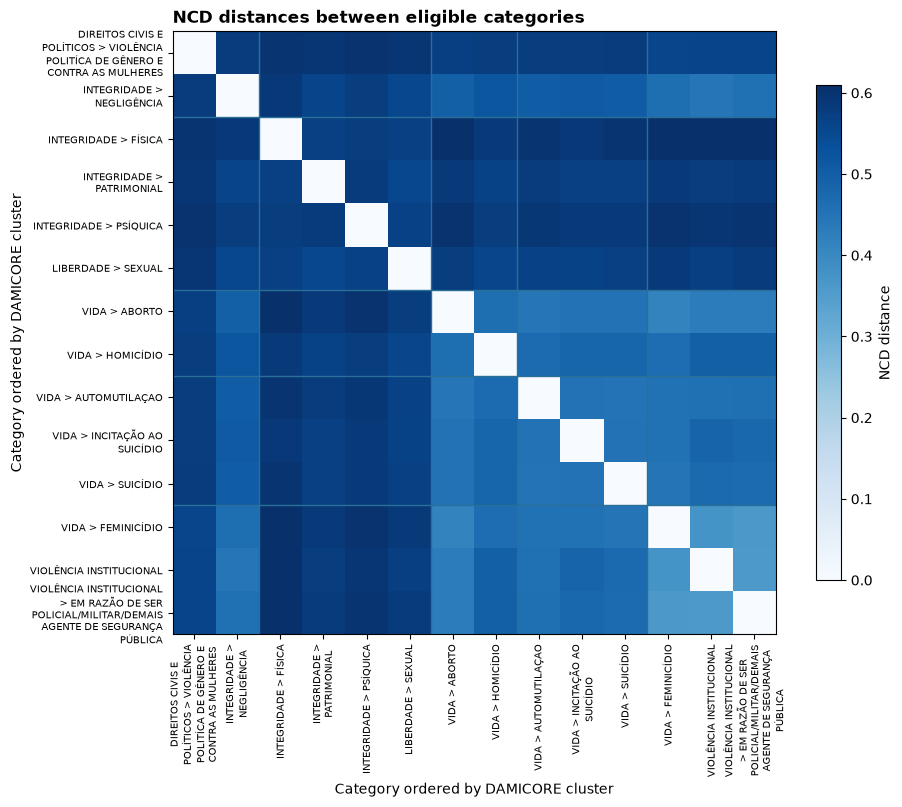

In [58]:
ncd_order = (
    category_clusters.sort_values(["cluster", "category"])["category"].tolist()
)
ncd_matrix = category_distance_matrix.loc[ncd_order, ncd_order]

figure, axis = plt.subplots(
    figsize=(max(10, 0.68 * len(ncd_order)), max(8, 0.58 * len(ncd_order))),
)
image = axis.imshow(
    ncd_matrix.to_numpy(),
    cmap="Blues",
    aspect="equal",
    vmin=0,
    vmax=float(np.nanmax(ncd_matrix.to_numpy())),
)
labels = [wrapped_label(category, width=24) for category in ncd_order]
axis.set_xticks(np.arange(len(labels)))
axis.set_xticklabels(labels, rotation=90, fontsize=7)
axis.set_yticks(np.arange(len(labels)))
axis.set_yticklabels(labels, fontsize=7)
axis.set_xlabel("Category ordered by DAMICORE cluster")
axis.set_ylabel("Category ordered by DAMICORE cluster")
axis.set_title("NCD distances between eligible categories", loc="left", weight="bold")
axis.grid(False)

cluster_boundaries = (
    category_clusters.groupby("cluster", sort=True).size().cumsum().tolist()
)
for boundary in cluster_boundaries[:-1]:
    axis.axhline(boundary - 0.5, color=VISUAL_STYLE["accent_color"], linewidth=1.0)
    axis.axvline(boundary - 0.5, color=VISUAL_STYLE["accent_color"], linewidth=1.0)

figure.colorbar(image, ax=axis, label="NCD distance", shrink=0.82)
figure.tight_layout()
figure.savefig(
    RESULTS_DIR / "category-ncd-heatmap.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()


## 6. Árvore de distância do DAMICORE

As folhas mostram os nomes reais das categorias. Categorias com caminhos de ligação menores têm desvios relativos de contexto mais semelhantes. A cor identifica o cluster DAMICORE; ela não representa uma classificação jurídica.


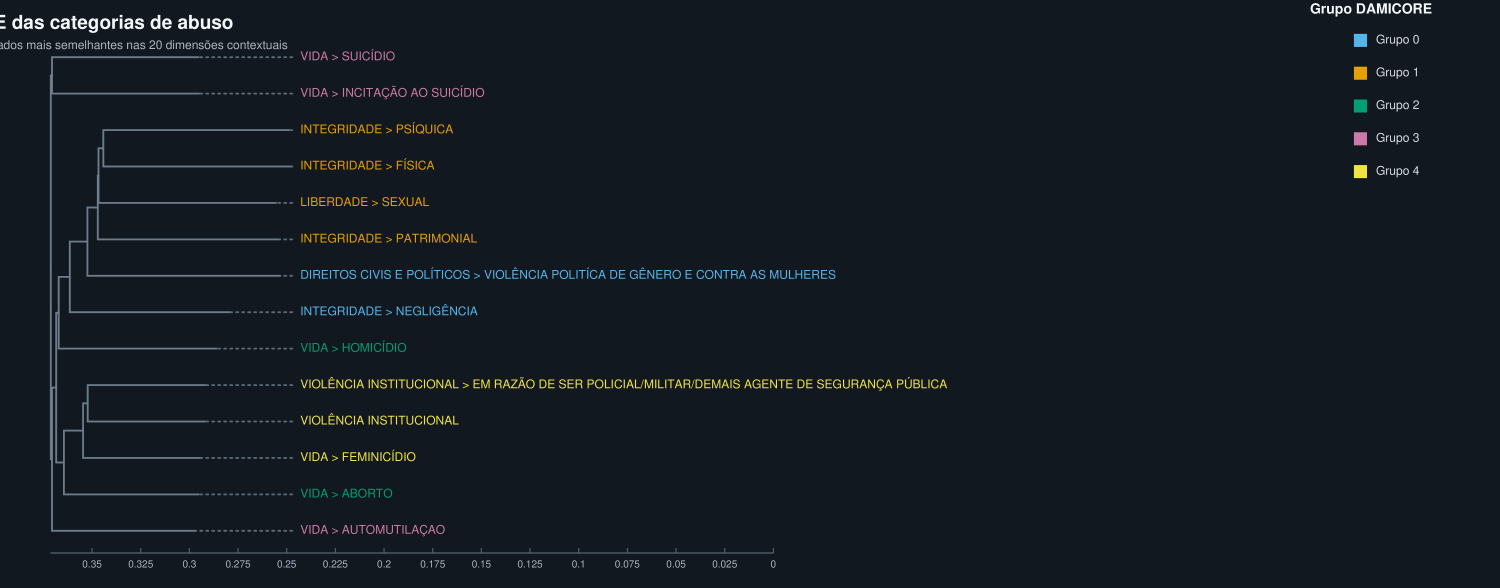

In [59]:
tree = toytree.tree(tree_newick)
by_object_id = category_clusters.set_index("object_id")
by_label = category_clusters.set_index("label")
tip_labels = []
tip_colors = []

def normalize_tip_name(tip_name):
    tip_name = str(tip_name).strip()
    if len(tip_name) >= 2 and tip_name[0] == tip_name[-1] and tip_name[0] in {"'", '"'}:
        return tip_name[1:-1]
    return tip_name

tree_tip_names = [
    normalize_tip_name(tip_name)
    for tip_name in tree.get_tip_labels()
]
known_tip_names = set(by_object_id.index) | set(by_label.index)
unknown_tip_names = sorted(set(tree_tip_names) - known_tip_names)
if unknown_tip_names:
    raise KeyError(f"Unknown DAMICORE tree leaf labels: {unknown_tip_names}")

for tip_name in tree_tip_names:
    if tip_name in by_object_id.index:
        category_row = by_object_id.loc[tip_name]
    elif tip_name in by_label.index:
        category_row = by_label.loc[tip_name]
    else:
        raise KeyError(f"Folha desconhecida na árvore DAMICORE: {tip_name}")
    cluster = int(category_row["cluster"])
    tip_labels.append(category_row["category"])
    tip_colors.append(cluster_hex_colors[cluster])

if len(tip_labels) != len(category_clusters):
    raise ValueError("A árvore DAMICORE não corresponde às categorias esperadas.")

canvas, axes, mark = tree.draw(
    tree_style="d",
    layout="r",
    width=1500,
    height=max(480, len(category_clusters) * 42),
    tip_labels=tip_labels,
    tip_labels_colors=tip_colors,
    tip_labels_align=True,
    tip_labels_style={"font-size": "12px", "font-family": "Helvetica"},
    node_labels=False,
    node_mask=False,
    edge_style={
        "stroke": "#718090",
        "stroke-width": 1.8,
        "stroke-opacity": 0.95,
    },
    edge_align_style={
        "stroke": "#5D6C7A",
        "stroke-width": 1.8,
        "stroke-opacity": 0.95,
        "stroke-dasharray": "2,4",
    },
    scale_bar=True,
)
canvas.style = {"background-color": "#121820"}
axes.x.spine.style = {"stroke": "#556474", "stroke-width": 1.2}
axes.x.ticks.style = {"stroke": "#556474", "stroke-width": 1.0}
axes.x.ticks.labels.style = {"fill": "#AAB7C4", "font-family": "Helvetica"}
canvas.text(35, 24, "Árvore DAMICORE das categorias de abuso", style={"font-size": "19px", "font-weight": "bold", "fill": "#F4F7FA"})
canvas.text(35, 46, "Categorias próximas têm perfis normalizados mais semelhantes nas 20 dimensões contextuais", style={"font-size": "12px", "fill": "#AAB7C4"})
legend_markers = [
    (
        f"Grupo {cluster}",
        toyplot.marker.create(
            shape="s",
            size=12,
            mstyle={"fill": cluster_hex_colors[cluster], "stroke": cluster_hex_colors[cluster]},
        ),
    )
    for cluster in clusters
]
legend = canvas.legend(
    legend_markers,
    corner=("top-right", 24, 210, max(72, 28 * len(clusters) + 24)),
    label="Grupo DAMICORE",
)
legend.label.style = {"fill": "#F4F7FA", "font-family": "Helvetica"}
legend.cells.column[1].lstyle = {"fill": "#D4DCE4", "font-family": "Helvetica"}
toytree.save(canvas, RESULTS_DIR / "category-tree.html")
toytree.save(canvas, RESULTS_DIR / "category-tree.svg")
canvas


## Limite de interpretação

O DAMICORE agrupa categorias elegíveis da fonte cujos desvios relativos de contexto demográfico, do processo de registro, da relação, do ambiente, do mês e das demais 20 dimensões são comprimidos de forma semelhante. Interprete a árvore e os agrupamentos somente quando o diagnóstico de viés for aceitável. A motivação pode aproximar categorias por conteúdo semântico, enquanto os campos socioeconômicos e étnicos podem ter ausência elevada. Mesmo assim, os clusters são perfis contextuais exploratórios, não tipologias jurídicas ou sociais confirmadas de abuso; as categorias esparsas excluídas precisam de uma análise descritiva separada.


## 7. Segundo experimento — corpus de denúncias completas

O experimento normalized acima permanece como a abordagem agregada de referência, agora ampliada para as mesmas 20 dimensões usadas nos casos. Esta seção cria um arquivo por categoria com uma linha canônica para cada source_hash distinto da categoria. A linha mantém os valores das 20 dimensões juntos dentro da denúncia.

Serão comparados dois regimes: case-full, com todos os casos distintos, e case-balanced, com o mesmo número de casos por categoria. O balanceamento é uniforme por source_hash, sem reposição dentro de uma réplica; combinações frequentes continuam mais frequentes porque correspondem a mais denúncias distintas.


In [60]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.damicore_case_experiment import (
    CASE_COLUMNS,
    CASE_FIELDS,
    build_case_corpora,
    compare_combination_distributions,
    load_case_records,
)
assert len(CASE_FIELDS) == 20
assert len(CASE_COLUMNS) == 20
assert {label for _, label in CASE_FIELDS} == expected_dimension_labels


CASE_SEEDS = [101, 202, 303, 404, 505]
CASE_WORK_DIR = WORK_DIR / "case-corpus"
CASE_CATEGORY_MAP_PATH = CASE_WORK_DIR / "case-category-map.csv"
CASE_COMBINATION_COUNTS_PATH = CASE_WORK_DIR / "case-combination-counts.csv"
CASE_COMBINATION_COMPARISON_PATH = CASE_WORK_DIR / "case-combination-comparison.csv"

normalized_distance_matrix = distance_matrix.copy()
normalized_membership = membership.copy()
normalized_category_clusters = category_clusters.copy()
normalized_corpus_sizes = corpus_sizes.copy()

case_records = load_case_records(
    database_url=DATABASE_URL,
    start_date=START_DATE,
    end_date=END_DATE,
    victim_gender=VICTIM_GENDER,
    included_categories=included_categories,
    category_sql=category_sql,
)

case_support = (
    case_records.groupby("category", as_index=False)["source_hash"]
    .nunique()
    .rename(columns={"source_hash": "case_count"})
)
expected_support = included_support[["category", "category_report_count"]].rename(
    columns={"category_report_count": "expected_case_count"}
)
case_support_check = expected_support.merge(
    case_support, on="category", validate="one_to_one"
)
assert (
    case_support_check["expected_case_count"]
    == case_support_check["case_count"]
).all()

case_category_map, case_combination_counts, balanced_sample_size = build_case_corpora(
    case_records=case_records,
    category_map=category_map,
    work_dir=WORK_DIR,
    seeds=CASE_SEEDS,
)
case_combination_comparison = compare_combination_distributions(
    case_combination_counts,
    CASE_COMBINATION_COMPARISON_PATH,
)

print(f"Casos categoria-relatório: {len(case_records):,}")
print(f"Tamanho balanceado por réplica: {balanced_sample_size:,}")
print(f"Réplicas balanceadas: {len(CASE_SEEDS)}")
display(case_support.sort_values("case_count", ascending=False))
display(
    case_records[["category", "canonical_record"]].head(3)
)


Casos categoria-relatório: 3,428,019
Tamanho balanceado por réplica: 247
Réplicas balanceadas: 5


,category,case_count
4,INTEGRIDADE > PSÍQUICA,1121598
1,INTEGRIDADE > FÍSICA,1100754
2,INTEGRIDADE > NEGLIGÊNCIA,835748
3,INTEGRIDADE > PATRIMONIAL,200197
5,LIBERDADE > SEXUAL,147380
12,VIOLÊNCIA INSTITUCIONAL,12482
13,VIOLÊNCIA INSTITUCIONAL > EM RAZÃO DE SER POLI...,2792
10,VIDA > INCITAÇÃO AO SUICÍDIO,1954
9,VIDA > HOMICÍDIO,1517
7,VIDA > AUTOMUTILAÇAO,1322


,category,canonical_record
0,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,"{""faixa_etaria"":[""55 A 59 ANOS""],""relacao_viti..."
1,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,"{""faixa_etaria"":[""16 ANOS""],""relacao_vitima_su..."
2,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,"{""faixa_etaria"":[""30 A 34 ANOS""],""relacao_viti..."


### 7.1 Construção dos documentos de casos

O agrupamento é feito no grão source_hash + category. Um mesmo relatório multilabel pode aparecer uma vez em mais de um arquivo de categoria, mas nunca mais de uma vez na mesma categoria. Os identificadores permanecem apenas na memória para validar o grão e não são gravados nos artefatos. Os campos com múltiplos valores são deduplicados, ordenados e serializados juntos.


In [61]:
print("Corpus completo:")
display(
    case_category_map.loc[
        case_category_map["regime"] == "case-full",
        ["label", "category", "case_count", "bytes"],
    ].sort_values("category")
)

print("Corpus balanceado:")
display(
    case_category_map.loc[
        case_category_map["regime"] == "case-balanced",
        ["replicate", "category", "case_count", "bytes"],
    ].sort_values(["replicate", "category"]).head(28)
)

assert case_category_map["case_count"].gt(0).all()
assert set(case_category_map["category"]) == set(included_categories)
assert case_category_map.loc[
    case_category_map["regime"] == "case-balanced", "case_count"
].eq(balanced_sample_size).all()
assert not case_records.duplicated(["source_hash", "category"]).any()
canonical_keys = case_records["canonical_record"].map(lambda value: set(json.loads(value)))
assert canonical_keys.map(lambda keys: not {"source_hash", "category", "id"}.intersection(keys)).all()
assert canonical_keys.map(lambda keys: keys == expected_dimension_labels).all()
assert case_combination_counts["case_count"].gt(0).all()
assert set(case_combination_counts["category"]) == set(included_categories)

case_combination_summary = (
    case_combination_comparison[
        ["category", "replicate", "absolute_share_difference"]
    ]
    .groupby(["category", "replicate"], as_index=False)
    .agg(
        mean_absolute_share_difference=(
            "absolute_share_difference",
            "mean",
        ),
        max_absolute_share_difference=(
            "absolute_share_difference",
            "max",
        ),
    )
)

# These large tables are persisted above and are no longer needed for DAMICORE.
del case_records, case_combination_counts, case_combination_comparison


Corpus completo:


,label,category,case_count,bytes
0,category-001.txt,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,247,183957
1,category-002.txt,INTEGRIDADE > FÍSICA,1100754,852633693
2,category-003.txt,INTEGRIDADE > NEGLIGÊNCIA,835748,621526723
3,category-004.txt,INTEGRIDADE > PATRIMONIAL,200197,148956170
4,category-005.txt,INTEGRIDADE > PSÍQUICA,1121598,853324280
5,category-006.txt,LIBERDADE > SEXUAL,147380,109810723
6,category-007.txt,VIDA > ABORTO,393,293195
7,category-008.txt,VIDA > AUTOMUTILAÇAO,1322,980592
8,category-009.txt,VIDA > FEMINICÍDIO,343,255877
9,category-010.txt,VIDA > HOMICÍDIO,1517,1123384


Corpus balanceado:


,replicate,category,case_count,bytes
14,replicate-001,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,247,183957
15,replicate-001,INTEGRIDADE > FÍSICA,247,191968
16,replicate-001,INTEGRIDADE > NEGLIGÊNCIA,247,183834
17,replicate-001,INTEGRIDADE > PATRIMONIAL,247,182684
18,replicate-001,INTEGRIDADE > PSÍQUICA,247,187264
19,replicate-001,LIBERDADE > SEXUAL,247,183680
20,replicate-001,VIDA > ABORTO,247,184239
21,replicate-001,VIDA > AUTOMUTILAÇAO,247,183566
22,replicate-001,VIDA > FEMINICÍDIO,247,184228
23,replicate-001,VIDA > HOMICÍDIO,247,183160


### 7.2 Execução dos regimes de casos

case-full mede similaridade contextual junto com prevalência e volume. Cada réplica case-balanced mede a estrutura das combinações sob suporte igual. O DAMICORE recebe os arquivos de linhas canônicas; as contagens explícitas ficam no CSV auxiliar.


In [62]:
CASE_FULL_EXECUTION = ExecutionConfig(
    workers=1,
    limits=ResourceLimits(
        max_working_memory_bytes=6 * 1024**3,
    ),
)

# Release any large tables if this cell is run after the setup cells from an older kernel.
import gc
if ("case_combination_summary" not in globals()) and ("case_combination_comparison" in globals()):
    case_combination_summary = (
        case_combination_comparison[
            ["category", "replicate", "absolute_share_difference"]
        ]
        .groupby(["category", "replicate"], as_index=False)
        .agg(
            mean_absolute_share_difference=(
                "absolute_share_difference",
                "mean",
            ),
            max_absolute_share_difference=(
                "absolute_share_difference",
                "max",
            ),
        )
    )
for _name in ("case_records", "case_combination_counts", "case_combination_comparison"):
    globals().pop(_name, None)
gc.collect()

def run_case_damicore(experiment_name, corpus_dir):
    execution = CASE_FULL_EXECUTION if experiment_name == "case-full" else None
    preview = estimate(
        corpus_dir,
        source_kind="files",
        execution=execution,
    )
    preview_data = preview.model_dump()
    preview_data["experiment"] = experiment_name
    print(
        f"{experiment_name}: "
        f"{preview.object_count} objects, "
        f"{preview.pair_count} pairs, "
        f"{preview.input_size_bytes:,} input bytes"
    )

    if not preview.within_limits:
        preview_data["status"] = "resource_limit"
        return {
            "name": experiment_name,
            "preview": preview_data,
            "status": "resource_limit",
            "corpus_dir": corpus_dir,
        }

    output_dir = CASE_WORK_DIR / f"{experiment_name}-run"
    result = run(
        corpus_dir,
        source_kind="files",
        output_dir=output_dir,
        execution=execution,
    )
    try:
        result_data = {
            "membership": result.membership.copy(),
            "distance_matrix": result.distance_matrix.to_pandas(),
            "tree_newick": result.tree_newick,
        }
    finally:
        result.close()

    preview_data["status"] = "completed"
    result_data.update(
        {
            "name": experiment_name,
            "preview": preview_data,
            "status": "completed",
            "corpus_dir": corpus_dir,
            "output_dir": output_dir,
        }
    )
    return result_data

case_results = {}
case_results["case-full"] = run_case_damicore(
    "case-full",
    CASE_WORK_DIR / "full",
)
for replicate in [f"replicate-{index:03d}" for index in range(1, len(CASE_SEEDS) + 1)]:
    experiment_name = f"case-balanced-{replicate}"
    case_results[experiment_name] = run_case_damicore(
        experiment_name,
        CASE_WORK_DIR / "balanced" / replicate,
    )

case_run_summary = pd.DataFrame(
    [
        {
            "experiment": name,
            "status": data["status"],
            "object_count": data["preview"].get("object_count"),
            "pair_count": data["preview"].get("pair_count"),
            "input_size_bytes": data["preview"].get("input_size_bytes"),
            "output_dir": str(data.get("output_dir", "")),
        }
        for name, data in case_results.items()
    ]
)
case_run_summary.to_csv(CASE_WORK_DIR / "case-run-summary.csv", index=False)
display(case_run_summary)


case-full: 14 objects, 91 pairs, 2,602,985,143 input bytes


distance: 100%|██████████| 91/91 [02:27<00:00,  1.62s/pair]


case-balanced-replicate-001: 14 objects, 91 pairs, 2,584,229 input bytes


distance: 100%|██████████| 91/91 [00:01<00:00, 63.42pair/s]


case-balanced-replicate-002: 14 objects, 91 pairs, 2,586,712 input bytes


...

case-balanced-replicate-004: 14 objects, 91 pairs, 2,589,358 input bytes


distance: 100%|██████████| 91/91 [00:00<00:00, 211.52pair/s]


case-balanced-replicate-005: 14 objects, 91 pairs, 2,590,245 input bytes


distance: 100%|██████████| 91/91 [00:00<00:00, 206.77pair/s]


,experiment,status,object_count,pair_count,input_size_bytes,output_dir
0,case-full,completed,14,91,2602985143,/Users/erickpatrickbarcelos/codes/data-mining/...
1,case-balanced-replicate-001,completed,14,91,2584229,/Users/erickpatrickbarcelos/codes/data-mining/...
2,case-balanced-replicate-002,completed,14,91,2586712,/Users/erickpatrickbarcelos/codes/data-mining/...
3,case-balanced-replicate-003,completed,14,91,2585708,/Users/erickpatrickbarcelos/codes/data-mining/...
4,case-balanced-replicate-004,completed,14,91,2589358,/Users/erickpatrickbarcelos/codes/data-mining/...
5,case-balanced-replicate-005,completed,14,91,2590245,/Users/erickpatrickbarcelos/codes/data-mining/...


,experiment,html,svg
0,normalized,/Users/erickpatrickbarcelos/codes/data-mining/...,/Users/erickpatrickbarcelos/codes/data-mining/...
1,case-full,/Users/erickpatrickbarcelos/codes/data-mining/...,/Users/erickpatrickbarcelos/codes/data-mining/...
2,case-balanced-replicate-001,/Users/erickpatrickbarcelos/codes/data-mining/...,/Users/erickpatrickbarcelos/codes/data-mining/...
3,case-balanced-replicate-002,/Users/erickpatrickbarcelos/codes/data-mining/...,/Users/erickpatrickbarcelos/codes/data-mining/...
4,case-balanced-replicate-003,/Users/erickpatrickbarcelos/codes/data-mining/...,/Users/erickpatrickbarcelos/codes/data-mining/...
5,case-balanced-replicate-004,/Users/erickpatrickbarcelos/codes/data-mining/...,/Users/erickpatrickbarcelos/codes/data-mining/...
6,case-balanced-replicate-005,/Users/erickpatrickbarcelos/codes/data-mining/...,/Users/erickpatrickbarcelos/codes/data-mining/...


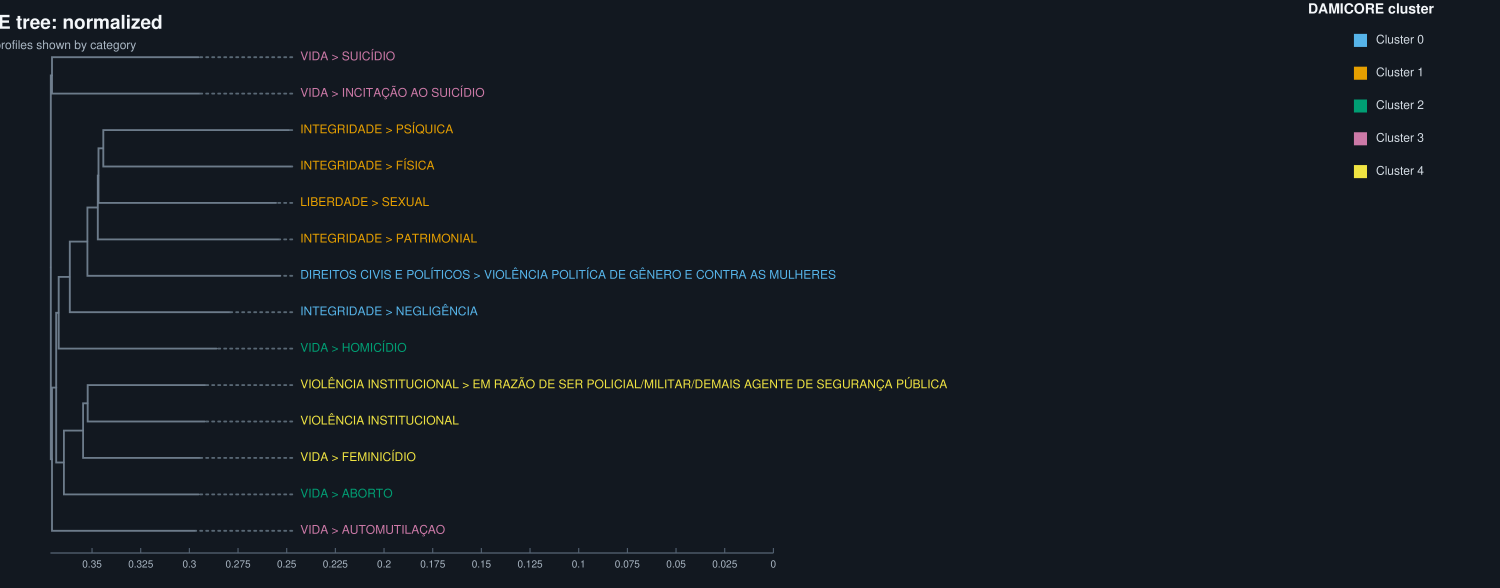

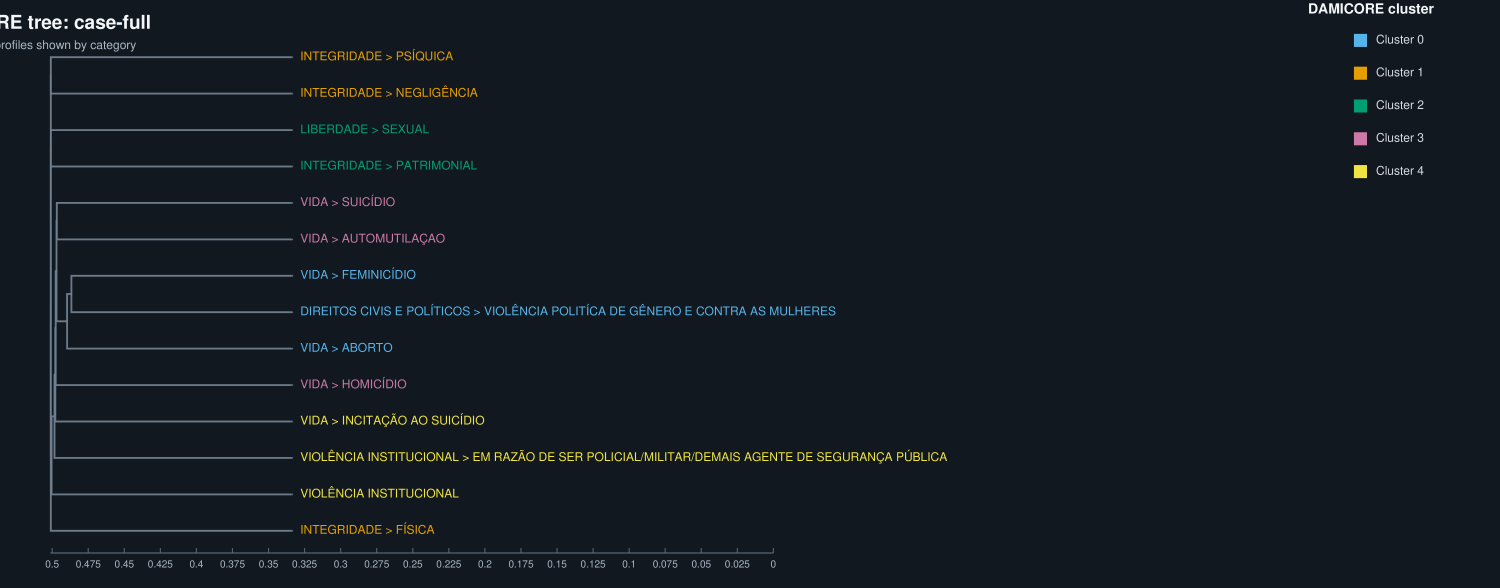

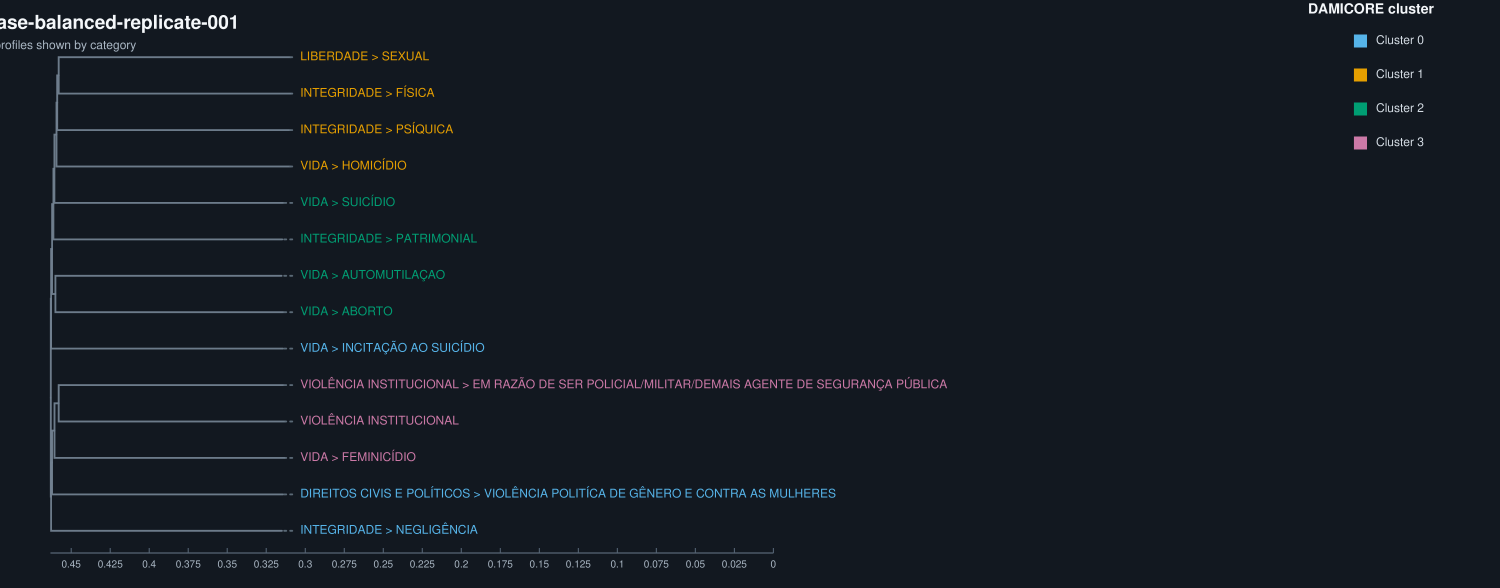

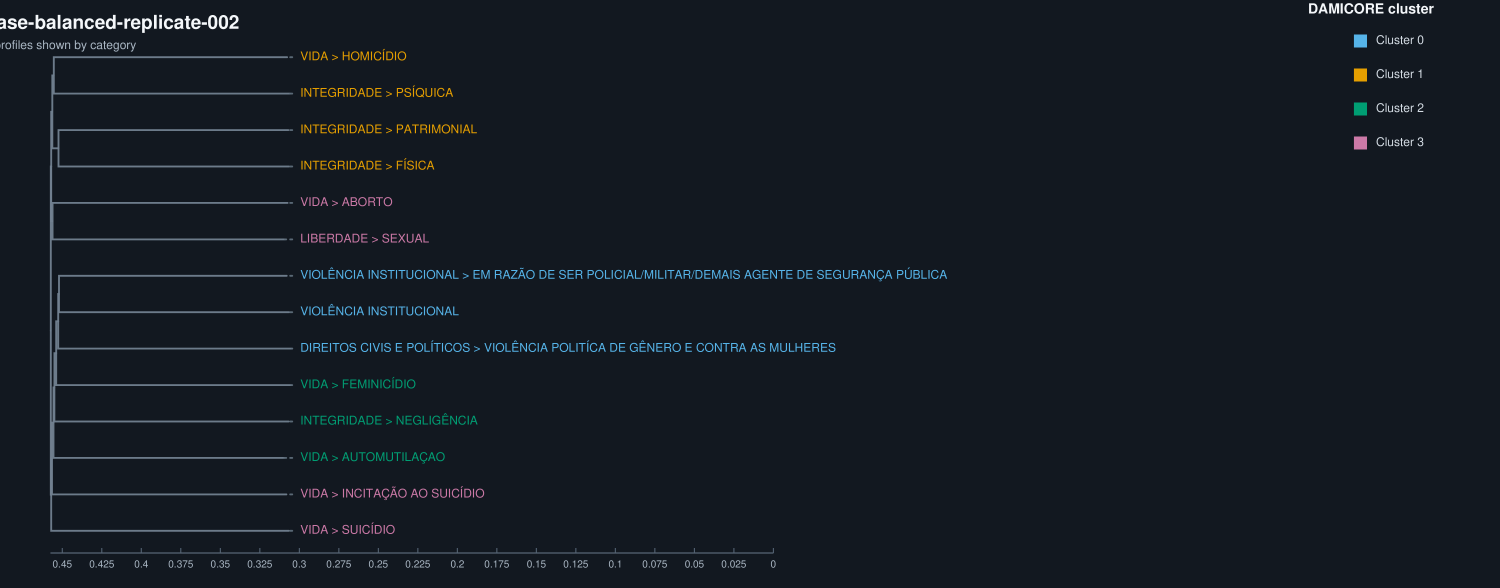

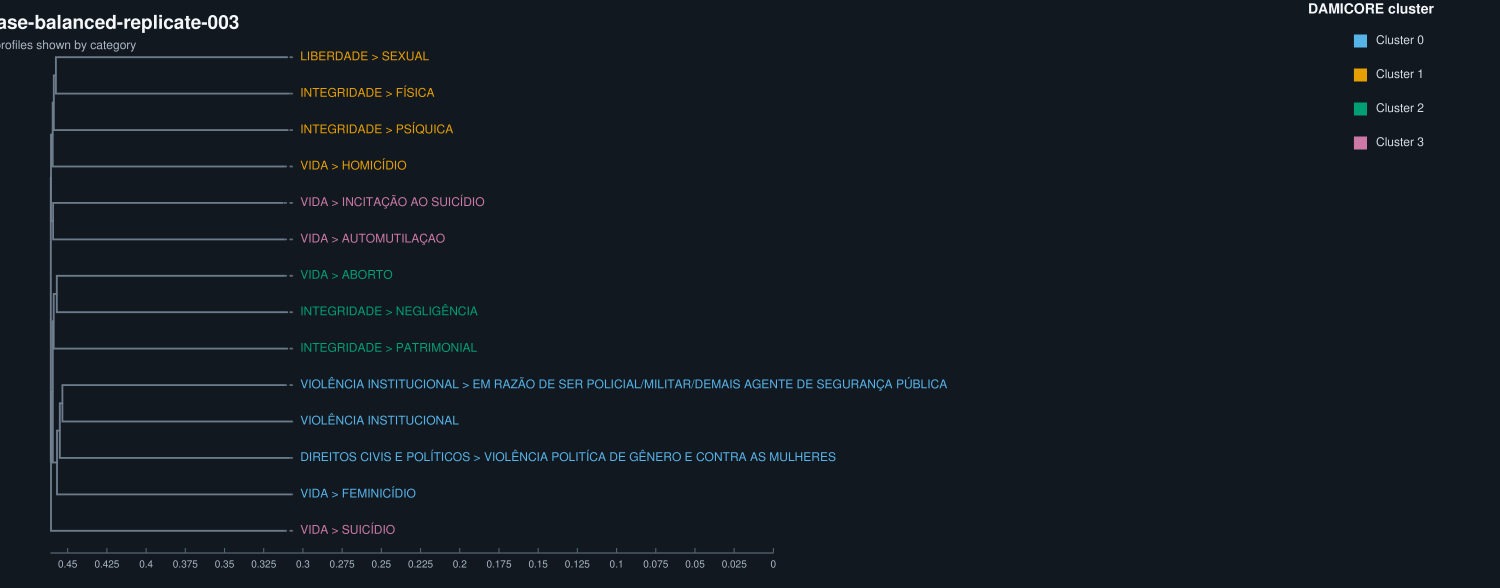

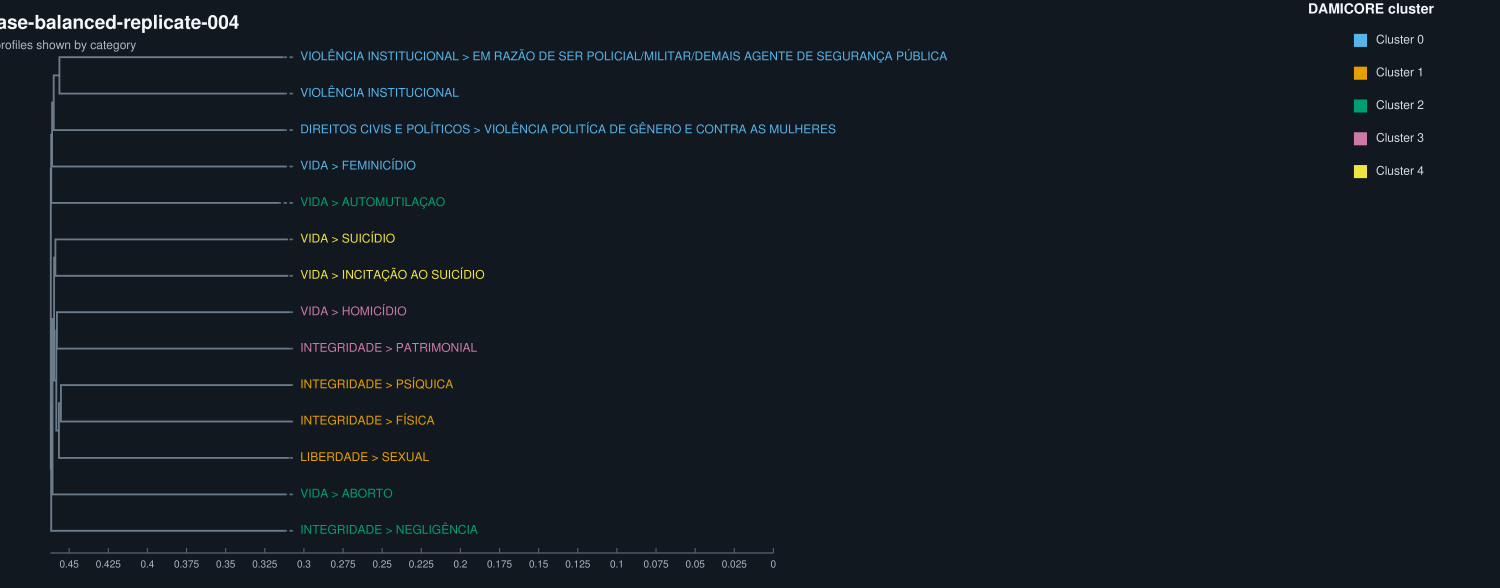

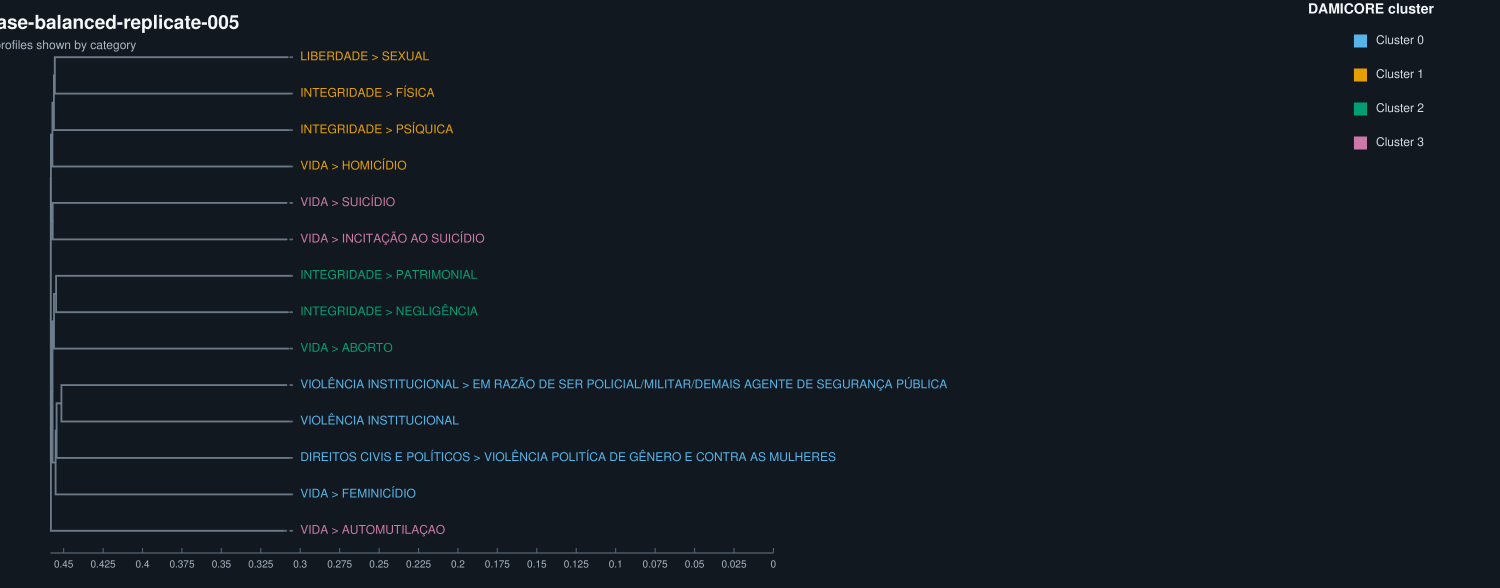

In [68]:
CASE_TREE_RESULTS_DIR = RESULTS_DIR / "case-trees"
CASE_TREE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def draw_experiment_tree(experiment_name, tree_newick, membership_table):
    tree = toytree.tree(tree_newick)
    membership_by_object_id = membership_table.set_index("object_id")
    membership_by_label = membership_table.set_index("label")
    category_by_label = category_map.set_index("label")["category"].to_dict()
    tree_tip_names = []
    tip_labels = []
    tip_colors = []

    for raw_tip_name in tree.get_tip_labels():
        tip_name = str(raw_tip_name).strip()
        if len(tip_name) >= 2 and tip_name[0] == tip_name[-1] and tip_name[0] in {"'", '"'}:
            tip_name = tip_name[1:-1]
        tree_tip_names.append(tip_name)
        if tip_name in membership_by_object_id.index:
            membership_row = membership_by_object_id.loc[tip_name]
        elif tip_name in membership_by_label.index:
            membership_row = membership_by_label.loc[tip_name]
        else:
            raise KeyError(f"Unknown DAMICORE tree leaf label: {tip_name}")
        label = membership_row["label"]
        cluster = int(membership_row["cluster"])
        tip_labels.append(category_by_label[label])
        tip_colors.append(cluster_hex_colors[cluster])

    if len(tip_labels) != len(membership_table):
        raise ValueError(f"Tree {experiment_name} does not match its membership table.")

    canvas, axes, mark = tree.draw(
        tree_style="d",
        layout="r",
        width=1500,
        height=max(480, len(tip_labels) * 42),
        tip_labels=tip_labels,
        tip_labels_colors=tip_colors,
        tip_labels_align=True,
        tip_labels_style={"font-size": "12px", "font-family": "Helvetica"},
        node_labels=False,
        node_mask=False,
        edge_style={"stroke": "#718090", "stroke-width": 1.8, "stroke-opacity": 0.95},
        edge_align_style={"stroke": "#5D6C7A", "stroke-width": 1.8, "stroke-opacity": 0.95, "stroke-dasharray": "2,4"},
        scale_bar=True,
    )
    canvas.style = {"background-color": "#121820"}
    axes.x.spine.style = {"stroke": "#556474", "stroke-width": 1.2}
    axes.x.ticks.style = {"stroke": "#556474", "stroke-width": 1.0}
    axes.x.ticks.labels.style = {"fill": "#AAB7C4", "font-family": "Helvetica"}
    canvas.text(35, 24, f"DAMICORE tree: {experiment_name}", style={"font-size": "19px", "font-weight": "bold", "fill": "#F4F7FA"})
    canvas.text(35, 46, "Contextual profiles shown by category", style={"font-size": "12px", "fill": "#AAB7C4"})
    legend_markers = [
        (
            f"Cluster {cluster}",
            toyplot.marker.create(
                shape="s",
                size=12,
                mstyle={"fill": cluster_hex_colors[cluster], "stroke": cluster_hex_colors[cluster]},
            ),
        )
        for cluster in sorted(set(membership_table["cluster"]))
    ]
    legend = canvas.legend(
        legend_markers,
        corner=("top-right", 24, 210, max(72, 28 * len(legend_markers) + 24)),
        label="DAMICORE cluster",
    )
    legend.label.style = {"fill": "#F4F7FA", "font-family": "Helvetica"}
    legend.cells.column[1].lstyle = {"fill": "#D4DCE4", "font-family": "Helvetica"}
    output_stem = experiment_name.replace("/", "-")
    html_path = CASE_TREE_RESULTS_DIR / f"{output_stem}.html"
    svg_path = CASE_TREE_RESULTS_DIR / f"{output_stem}.svg"
    toytree.save(canvas, html_path)
    toytree.save(canvas, svg_path)
    return canvas, html_path, svg_path

tree_experiments = [("normalized", tree_newick, normalized_membership)]
tree_experiments.extend(
    (name, data["tree_newick"], data["membership"])
    for name, data in case_results.items()
    if data["status"] == "completed"
)

tree_artifacts = []
tree_canvases = []
for experiment_name, experiment_tree, experiment_membership in tree_experiments:
    canvas, html_path, svg_path = draw_experiment_tree(
        experiment_name, experiment_tree, experiment_membership
    )
    tree_canvases.append(canvas)
    tree_artifacts.append({"experiment": experiment_name, "html": str(html_path), "svg": str(svg_path)})

tree_artifact_summary = pd.DataFrame(tree_artifacts)
display(tree_artifact_summary)
missing_tree_experiments = [
    name for name, data in case_results.items() if data["status"] != "completed"
]
if missing_tree_experiments:
    print(f"Trees not generated because the experiment was not completed: {missing_tree_experiments}")

# Render every canvas inline; returning the list only shows Python object representations.
for canvas in tree_canvases:
    display(canvas)


### 7.3 Comparação entre as abordagens

A comparação separa similaridade contextual, efeito do suporte e estabilidade das partições. Se case-full e case-balanced forem semelhantes, o volume não controla sozinho o agrupamento. Se divergirem, essa divergência mostra que a prevalência participa da estrutura comprimida.

> A figura de concordância abaixo não é uma matriz de distância: ela mostra a correlação de Spearman entre os rankings das distâncias NCD de cada experimento. Por isso, a diagonal é `1.0` por autocorrelação. As matrizes NCD usadas pelos experimentos têm diagonal `0.0`.


Correlações entre matrizes:


/Users/erickpatrickbarcelos/codes/data-mining/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/erickpatrickbarcelos/codes/data-mining/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,left,right,spearman_correlation,mean_absolute_difference
0,normalized,case-full,0.669703,0.459528
1,normalized,case-balanced-replicate-001,0.407812,0.363875
2,normalized,case-balanced-replicate-002,0.400862,0.363142
3,normalized,case-balanced-replicate-003,0.402236,0.365660
4,normalized,case-balanced-replicate-004,0.475597,0.364424
5,normalized,case-balanced-replicate-005,0.471002,0.366907
6,case-full,case-balanced-replicate-001,0.323556,0.095653
7,case-full,case-balanced-replicate-002,0.203593,0.096386
8,case-full,case-balanced-replicate-003,0.237331,0.093868
9,case-full,case-balanced-replicate-004,0.454343,0.095104


Diagnóstico de suporte e tamanho:


,experiment,ncd_support_spearman,ncd_byte_spearman
0,normalized,0.587157,NaN
1,case-full,0.665647,0.909380
2,case-balanced-replicate-001,0.207566,0.366859
3,case-balanced-replicate-002,0.098966,0.119870
4,case-balanced-replicate-003,0.195923,0.200025
5,case-balanced-replicate-004,0.392956,0.195496
6,case-balanced-replicate-005,0.205409,0.146537


Estabilidade das réplicas balanceadas:


,left,right,pairwise_cluster_agreement
0,case-balanced-replicate-001,case-balanced-replicate-002,0.714286
1,case-balanced-replicate-001,case-balanced-replicate-003,0.846154
2,case-balanced-replicate-001,case-balanced-replicate-004,0.802198
3,case-balanced-replicate-001,case-balanced-replicate-005,0.846154
4,case-balanced-replicate-002,case-balanced-replicate-003,0.758242
5,case-balanced-replicate-002,case-balanced-replicate-004,0.802198
6,case-balanced-replicate-002,case-balanced-replicate-005,0.758242
7,case-balanced-replicate-003,case-balanced-replicate-004,0.890110
8,case-balanced-replicate-003,case-balanced-replicate-005,1.000000
9,case-balanced-replicate-004,case-balanced-replicate-005,0.890110


Distribuição das combinações:


,category,replicate,mean_absolute_share_difference,max_absolute_share_difference
0,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,replicate-001,0.000000,0.000000
1,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,replicate-002,0.000000,0.000000
2,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,replicate-003,0.000000,0.000000
3,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,replicate-004,0.000000,0.000000
4,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,replicate-005,0.000000,0.000000
5,INTEGRIDADE > FÍSICA,replicate-001,0.004047,0.004048
6,INTEGRIDADE > FÍSICA,replicate-002,0.004047,0.004048
7,INTEGRIDADE > FÍSICA,replicate-003,0.004047,0.004048
8,INTEGRIDADE > FÍSICA,replicate-004,0.004047,0.004048
9,INTEGRIDADE > FÍSICA,replicate-005,0.004047,0.004048


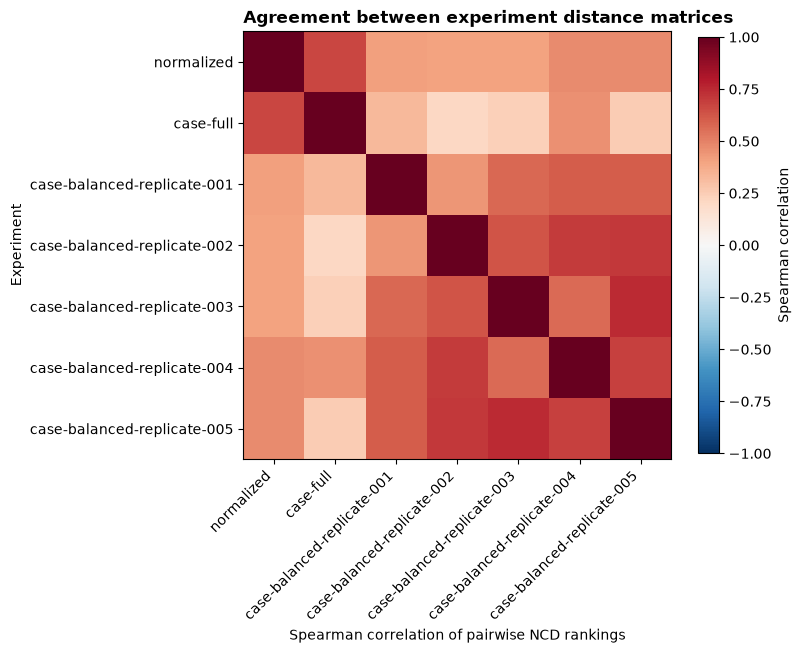

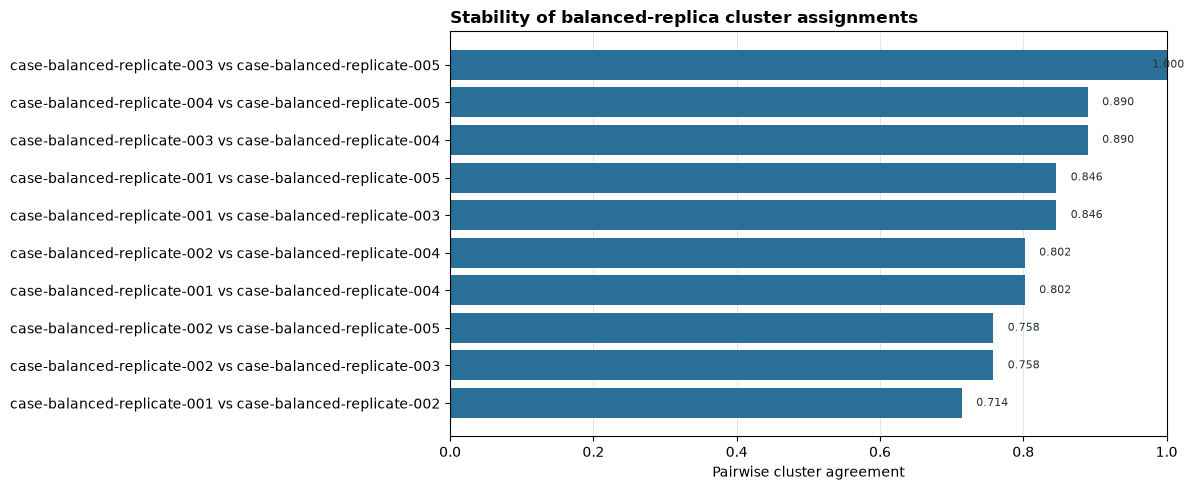

In [64]:
def category_named_distance(matrix):
    label_to_category = category_map.set_index("label")["category"].to_dict()
    renamed = matrix.rename(index=label_to_category, columns=label_to_category)
    return renamed.loc[included_categories, included_categories]

distance_matrices = {
    "normalized": category_named_distance(normalized_distance_matrix)
}
for name, data in case_results.items():
    if data["status"] == "completed":
        distance_matrices[name] = category_named_distance(data["distance_matrix"])

for experiment_name, matrix in distance_matrices.items():
    diagonal = np.diag(matrix.to_numpy())
    if not np.allclose(diagonal, 0.0):
        raise ValueError(
            f"The NCD distance matrix for {experiment_name} must have a zero diagonal."
        )

distance_comparison_rows = []
for left_name, right_name in combinations(distance_matrices, 2):
    left_values = []
    right_values = []
    for left_category, right_category in combinations(included_categories, 2):
        left_values.append(
            distance_matrices[left_name].loc[left_category, right_category]
        )
        right_values.append(
            distance_matrices[right_name].loc[left_category, right_category]
        )

    left_series = pd.Series(left_values)
    right_series = pd.Series(right_values)
    distance_comparison_rows.append(
        {
            "left": left_name,
            "right": right_name,
            "spearman_correlation": left_series.rank().corr(
                right_series.rank()
            ),
            "mean_absolute_difference": (
                left_series - right_series
            ).abs().mean(),
        }
    )

distance_comparison = pd.DataFrame(distance_comparison_rows)
distance_comparison.to_csv(
    CASE_WORK_DIR / "case-distance-comparison.csv",
    index=False,
)

label_to_category = category_map.set_index("label")["category"].to_dict()
normalized_bytes_by_category = {
    label_to_category[label]: int(size)
    for label, size in normalized_corpus_sizes.items()
}
support_by_category = included_support.set_index("category")[
    "category_report_count"
].to_dict()


def ncd_diagnostics(matrix, bytes_by_category):
    rows = []
    for left, right in combinations(included_categories, 2):
        rows.append(
            {
                "ncd": float(matrix.loc[left, right]),
                "support_gap": abs(
                    log10(support_by_category[left])
                    - log10(support_by_category[right])
                ),
                "byte_gap": abs(
                    bytes_by_category[left] - bytes_by_category[right]
                ),
            }
        )

    diagnostics = pd.DataFrame(rows)
    return {
        "ncd_support_spearman": diagnostics["ncd"].rank().corr(
            diagnostics["support_gap"].rank()
        ),
        "ncd_byte_spearman": diagnostics["ncd"].rank().corr(
            diagnostics["byte_gap"].rank()
        ),
    }


diagnostic_rows = [
    {
        "experiment": "normalized",
        **ncd_diagnostics(
            distance_matrices["normalized"],
            normalized_bytes_by_category,
        ),
    }
]

for name, matrix in distance_matrices.items():
    if name == "normalized":
        continue

    if name == "case-full":
        byte_table = case_category_map.loc[
            case_category_map["regime"] == "case-full"
        ]
    else:
        replicate = name.removeprefix("case-balanced-")
        byte_table = case_category_map.loc[
            (case_category_map["regime"] == "case-balanced")
            & (case_category_map["replicate"] == replicate)
        ]

    diagnostic_rows.append(
        {
            "experiment": name,
            **ncd_diagnostics(
                matrix,
                byte_table.set_index("category")["bytes"].to_dict(),
            ),
        }
    )

ncd_diagnostics_table = pd.DataFrame(diagnostic_rows)
ncd_diagnostics_table.to_csv(
    CASE_WORK_DIR / "case-ncd-diagnostics.csv",
    index=False,
)

membership_rows = []
normalized_membership_table = normalized_membership[
    ["label", "cluster"]
].merge(
    category_map[["label", "category"]],
    on="label",
    validate="one_to_one",
)
normalized_membership_table["experiment"] = "normalized"
membership_rows.extend(normalized_membership_table.to_dict(orient="records"))

for name, data in case_results.items():
    if data["status"] != "completed":
        continue
    membership_table = data["membership"][
        ["label", "cluster"]
    ].merge(
        category_map[["label", "category"]],
        on="label",
        validate="one_to_one",
    )
    membership_table["experiment"] = name
    membership_rows.extend(membership_table.to_dict(orient="records"))

case_membership = pd.DataFrame(membership_rows)
case_membership.to_csv(
    CASE_WORK_DIR / "case-cluster-membership.csv",
    index=False,
)


def same_cluster_pairs(membership_table):
    cluster_by_category = membership_table.set_index("category")[
        "cluster"
    ].to_dict()
    return {
        tuple(sorted((left, right)))
        for left, right in combinations(included_categories, 2)
        if cluster_by_category[left] == cluster_by_category[right]
    }


balanced_memberships = {
    name: same_cluster_pairs(
        case_membership.loc[
            case_membership["experiment"] == name
        ]
    )
    for name in case_membership["experiment"].unique()
    if name.startswith("case-balanced-")
}
all_category_pairs = set(combinations(included_categories, 2))
stability_rows = []
for left_name, right_name in combinations(balanced_memberships, 2):
    left_pairs = balanced_memberships[left_name]
    right_pairs = balanced_memberships[right_name]
    stability_rows.append(
        {
            "left": left_name,
            "right": right_name,
            "pairwise_cluster_agreement": len(
                all_category_pairs - (left_pairs ^ right_pairs)
            ) / len(all_category_pairs),
        }
    )

cluster_stability = pd.DataFrame(stability_rows)
cluster_stability.to_csv(
    CASE_WORK_DIR / "case-balanced-cluster-stability.csv",
    index=False,
)

case_comparison_summary = pd.DataFrame(
    [
        {
            "experiment": name,
            "status": data["status"],
            "tree_available": data["status"] == "completed",
            "tree_path": str(
                data.get("output_dir", "") / "tree.nwk"
                if data.get("output_dir")
                else ""
            ),
        }
        for name, data in case_results.items()
    ]
)
case_comparison_summary.to_csv(
    CASE_WORK_DIR / "case-comparison-summary.csv",
    index=False,
)

print("Concordância entre matrizes NCD:")
display(distance_comparison)
print("Diagnóstico de suporte e tamanho:")
display(ncd_diagnostics_table)
print("Estabilidade das réplicas balanceadas:")
display(cluster_stability)
print("Distribuição das combinações:")
display(case_combination_summary.head(28))


if not distance_comparison.empty:
    comparison_names = list(distance_matrices)
    matrix_agreement_values = np.full(
        (len(comparison_names), len(comparison_names)),
        np.nan,
        dtype=float,
    )
    # Self-comparison is a Spearman correlation of 1.0; this is not an NCD distance.
    np.fill_diagonal(matrix_agreement_values, 1.0)
    for row in distance_comparison.itertuples(index=False):
        left_index = comparison_names.index(row.left)
        right_index = comparison_names.index(row.right)
        matrix_agreement_values[left_index, right_index] = row.spearman_correlation
        matrix_agreement_values[right_index, left_index] = row.spearman_correlation
    matrix_agreement = pd.DataFrame(
        matrix_agreement_values.copy(),
        index=comparison_names,
        columns=comparison_names,
    )

    figure, axis = plt.subplots(
        figsize=(max(8, 0.82 * len(comparison_names)), max(7, 0.72 * len(comparison_names))),
    )
    image = axis.imshow(
        matrix_agreement.to_numpy(),
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        aspect="equal",
    )
    axis.set_xticks(np.arange(len(comparison_names)))
    axis.set_xticklabels(comparison_names, rotation=45, ha="right")
    axis.set_yticks(np.arange(len(comparison_names)))
    axis.set_yticklabels(comparison_names)
    axis.set_title(
        "Agreement between experiment NCD matrices",
        loc="left",
        weight="bold",
    )
    axis.set_xlabel("Spearman correlation of pairwise NCD rankings")
    axis.set_ylabel("Experiment")
    figure.colorbar(image, ax=axis, label="Spearman correlation (self = 1.0)", shrink=0.82)
    figure.tight_layout()
    figure.savefig(
        RESULTS_DIR / "case-distance-agreement.png",
        dpi=180,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()
else:
    print("No completed case runs are available for the NCD-agreement figure.")

if not cluster_stability.empty:
    stability_plot = cluster_stability.copy()
    stability_plot["comparison"] = (
        stability_plot["left"] + " vs " + stability_plot["right"]
    )
    stability_plot = stability_plot.sort_values("pairwise_cluster_agreement")

    figure, axis = plt.subplots(
        figsize=(12, max(5, 0.42 * len(stability_plot))),
    )
    axis.barh(
        stability_plot["comparison"],
        stability_plot["pairwise_cluster_agreement"],
        color=VISUAL_STYLE["accent_color"],
    )
    axis.set_xlim(0, 1)
    axis.set_xlabel("Pairwise cluster agreement")
    axis.set_title(
        "Stability of balanced-replica cluster assignments",
        loc="left",
        weight="bold",
    )
    axis.grid(axis="x", color=VISUAL_STYLE["grid_color"], linewidth=0.7)
    axis.set_axisbelow(True)
    for position, value in enumerate(stability_plot["pairwise_cluster_agreement"]):
        axis.text(
            min(value + 0.02, 0.98),
            position,
            f"{value:.3f}",
            va="center",
            fontsize=8,
            color=VISUAL_STYLE["text_color"],
        )
    figure.tight_layout()
    figure.savefig(
        RESULTS_DIR / "case-cluster-stability.png",
        dpi=180,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()
else:
    print("Fewer than two completed balanced runs are available for stability.")


### 7.4 Critérios de interpretação

case-full mede similaridade contextual junto com prevalência e volume. case-balanced mede similaridade contextual sob suporte igual. Se os dois regimes produzirem partições semelhantes, o agrupamento é menos dependente do volume. Se divergirem, essa divergência é um resultado metodológico.

Clusters só devem ser interpretados quando as réplicas balanceadas forem estáveis, a associação com diferenças de tamanho não dominar e os padrões puderem ser descritos diretamente nas combinações dos campos. Nenhum regime produz tipologias jurídicas, causalidade ou inferência individual.
